# Annotation Rounds Analysis (updated)

Using `HAR_dataset_for_stats.csv` with separate status columns:
- `status_main`
- `status_secondary`

This notebook now uses **direct status stats only** (no coarse status).

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

ROOT = Path("..").resolve()
DATA_PATH = ROOT / "data/annotation_rounds/final_gold_dataset/HAR_dataset_for_stats.csv"

df = pd.read_csv(DATA_PATH)

# Basic cleaning
for c in ["status_main", "status_secondary", "corrected_action"]:
    if c in df.columns:
        df[c] = df[c].replace({"": pd.NA})

df["has_correction"] = df["corrected_action"].notna()

print(f"Rows: {len(df):,} | Videos: {df['video_uid'].nunique():,}")
print("Rounds:", df["round"].value_counts().to_dict())
df.head(3)

def camembert_chart(series, ax, title, label_min_pct=3.0):
    """Pie chart (camembert): legend + slice labels only for shares >= label_min_pct (%)."""
    vc = series.dropna().astype(str).value_counts()
    if vc.empty:
        ax.set_title(f"{title} (no data)")
        return
    colors = plt.cm.tab20(np.arange(len(vc)) % 20)

    def autopct_fmt(p):
        return f"{p:.1f}%" if p >= label_min_pct else ""

    wedges, _texts, _autotexts = ax.pie(
        vc.values,
        autopct=autopct_fmt,
        colors=colors,
        startangle=90,
        pctdistance=0.72,
    )
    ax.legend(
        wedges,
        list(vc.index),
        title="Class",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
    )
    ax.set_title(title)
    ax.set_aspect("equal")



Rows: 27,657 | Videos: 1,366
Rounds: {'r001': 15915, 'r002': 11742}


## 1) Status statistics (main + secondary)

status_main counts


,count,percent
status_main,,
Gold,24093,87.11
Bad,3564,12.89


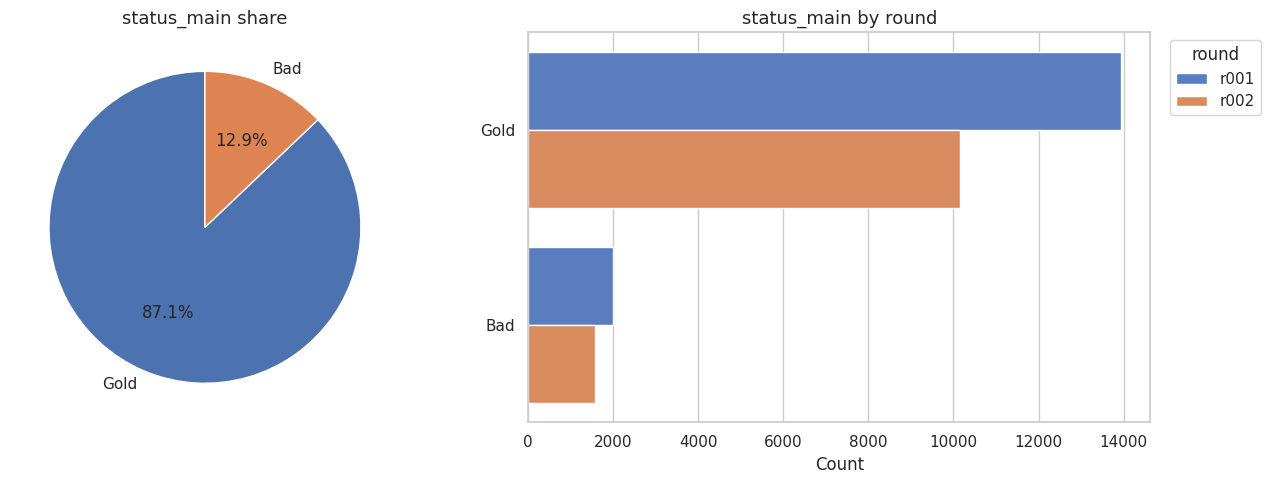

In [3]:
main_counts = df["status_main"].fillna("NA").value_counts()
main_pct = (100 * main_counts / main_counts.sum()).round(2)
print("status_main counts")
display(pd.DataFrame({"count": main_counts, "percent": main_pct}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(main_counts.values, labels=main_counts.index, autopct="%.1f%%", startangle=90)
axes[0].set_title("status_main share")

sns.countplot(
    data=df,
    y="status_main",
    order=main_counts.index,
    hue="round",
    palette="muted",
    ax=axes[1]
)
axes[1].set_title("status_main by round")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")
axes[1].legend(title="round", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Bad rate by scenario and action (`status_main == "Bad"`, Gardening excluded)

Same logic as the overall status plots, but **rows with `scenario == "Gardening"` are dropped** (matches common training exclusions).

- **Horizontal bars**: % of rows labeled **Bad** within each **scenario** and each **action** (class). Annotations show **n** (row count) so you can judge reliability.
- **Heatmap**: **scenario × action** with % Bad; cells with **n < MIN_N** are blanked to avoid noisy rates.


Rows after excluding Gardening: 26,645 (full df: 27,657)


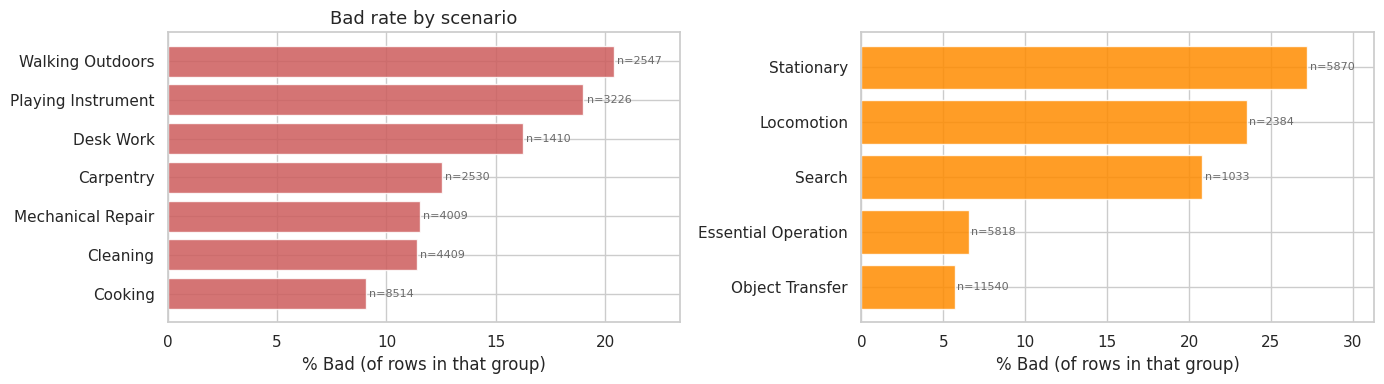

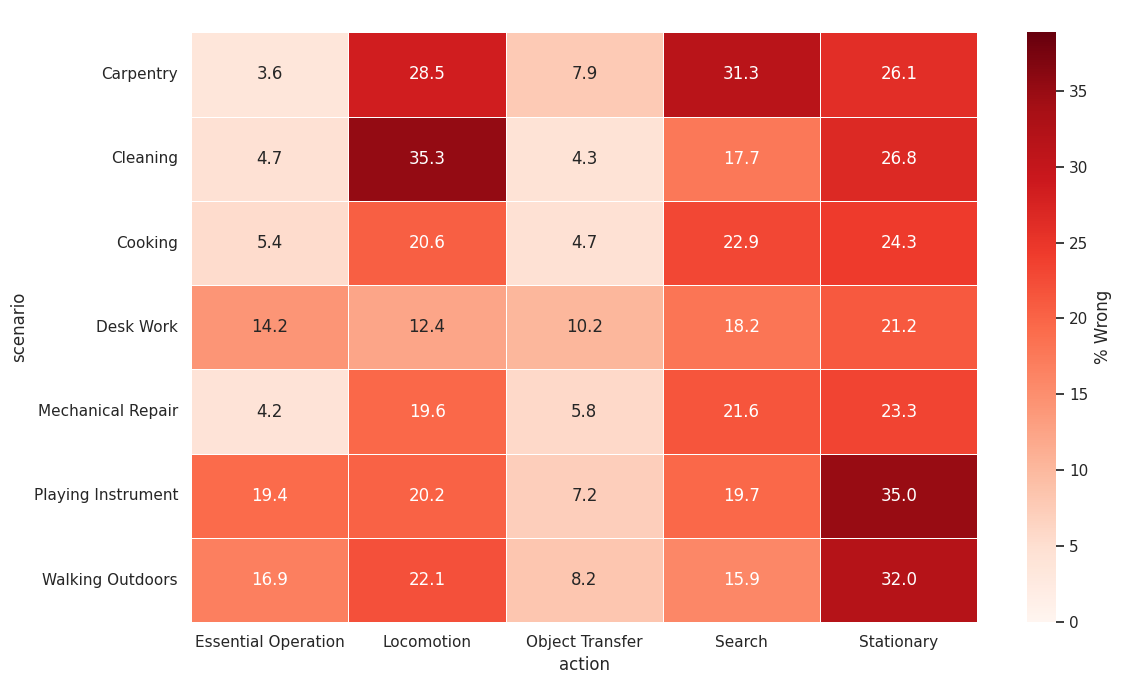

Tables (sorted by % Wrong labels, descending):

By scenario:


,n,bad,pct_bad
scenario,,,
Walking Outdoors,2547,519,20.38
Playing Instrument,3226,613,19.00
Desk Work,1410,229,16.24
Carpentry,2530,317,12.53
Mechanical Repair,4009,462,11.52
Cleaning,4409,502,11.39
Cooking,8514,772,9.07



By action:


,n,bad,pct_bad
action,,,
Stationary,5870,1597,27.21
Locomotion,2384,561,23.53
Search,1033,215,20.81
Essential Operation,5818,382,6.57
Object Transfer,11540,659,5.71


In [9]:
# % rows where status_main is exactly "Bad" (excluding Gardening scenario)
d = df.copy()
d = d[d["scenario"].astype(str) != "Gardening"]
print(f"Rows after excluding Gardening: {len(d):,} (full df: {len(df):,})")
d["is_bad"] = d["status_main"].eq("Bad")

# --- Aggregate: bad rate + counts ---
def bad_rate_table(group_col):
    return (
        d.groupby(group_col, dropna=False)
        .agg(n=("is_bad", "count"), bad=("is_bad", "sum"))
        .assign(pct_bad=lambda x: 100 * x["bad"] / x["n"])
        .sort_values("pct_bad", ascending=True)
    )

by_scenario = bad_rate_table("scenario")
by_action = bad_rate_table("action")

# --- Heatmap: P(bad | scenario, action) ---
MIN_N = 15  # lower if you want more cells filled
ct_n = d.groupby(["scenario", "action"], dropna=False).size().unstack(fill_value=0)
ct_bad = d[d["is_bad"]].groupby(["scenario", "action"], dropna=False).size().unstack(fill_value=0)
ct_bad = ct_bad.reindex(index=ct_n.index, columns=ct_n.columns, fill_value=0)
pct_grid = (ct_bad / ct_n.replace(0, np.nan)) * 100
mask_sparse = ct_n < MIN_N
pct_plot = pct_grid.mask(mask_sparse)

# --- Plot 1–2: horizontal bars ---
def plot_bad_bars(tbl, title, ax, color="indianred"):
    y = np.arange(len(tbl))
    ax.barh(y, tbl["pct_bad"], color=color, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(list(tbl.index))
    ax.set_xlabel("% Bad (of rows in that group)")
    ax.set_title(title)
    ax.set_xlim(0, max(tbl["pct_bad"].max() * 1.15, 5))
    for i, (idx, row) in enumerate(tbl.iterrows()):
        ax.text(
            row["pct_bad"] + 0.15,
            i,
            f"n={int(row['n'])}",
            va="center",
            fontsize=8,
            color="dimgray",
        )

h1 = max(4.0, 0.35 * len(by_scenario))
h2 = max(4.0, 0.35 * len(by_action))
fig, axes = plt.subplots(1, 2, figsize=(14, max(h1, h2)))
plot_bad_bars(by_scenario, "Bad rate by scenario", axes[0])
plot_bad_bars(by_action, " ", axes[1], color="darkorange")
plt.tight_layout()
plt.show()

# --- Plot 3: heatmap ---
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pct_plot,
    ax=ax,
    cmap="Reds",
    vmin=0,
    vmax=min(100, float(np.nanmax(pct_plot.values)) * 1.1) if np.isfinite(pct_plot.values).any() else 100,
    cbar_kws={"label": "% Wrong"},
    
    linewidths=0.5,
    linecolor="white",
    annot=pct_plot.round(1),
    fmt=".1f",
    mask=pct_plot.isna(),
)
ax.set_title(f" ")
ax.set_xlabel("action")
ax.set_ylabel("scenario")
plt.tight_layout()
plt.show()

print("Tables (sorted by % Wrong labels, descending):")
print("\nBy scenario:")
display(by_scenario.sort_values("pct_bad", ascending=False).round(2))
print("\nBy action:")
display(by_action.sort_values("pct_bad", ascending=False).round(2))



status_secondary counts


,count,percent
status_secondary,,
NA,27657,100.0


/tmp/ipykernel_1448991/1001244292.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="status_secondary", order=sec_counts.index, ax=ax, palette="pastel")
/tmp/ipykernel_1448991/1001244292.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(data=df, x="status_secondary", order=sec_counts.index, ax=ax, palette="pastel")


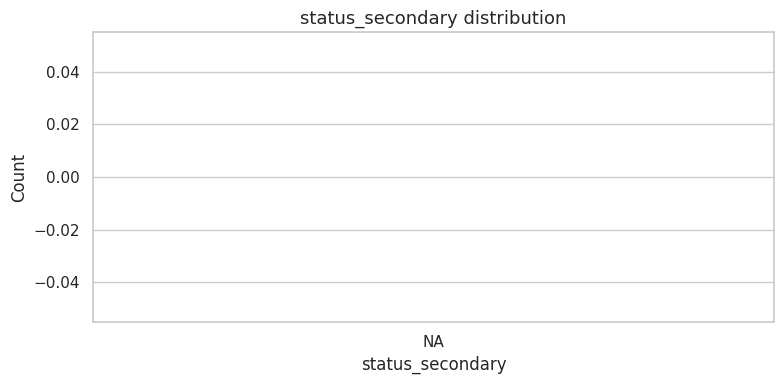

In [6]:
sec_counts = df["status_secondary"].fillna("NA").value_counts()
sec_pct = (100 * sec_counts / sec_counts.sum()).round(2)
print("status_secondary counts")
display(pd.DataFrame({"count": sec_counts, "percent": sec_pct}))

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x="status_secondary", order=sec_counts.index, ax=ax, palette="pastel")
ax.set_title("status_secondary distribution")
ax.set_xlabel("status_secondary")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 2) Scenario and class distributions

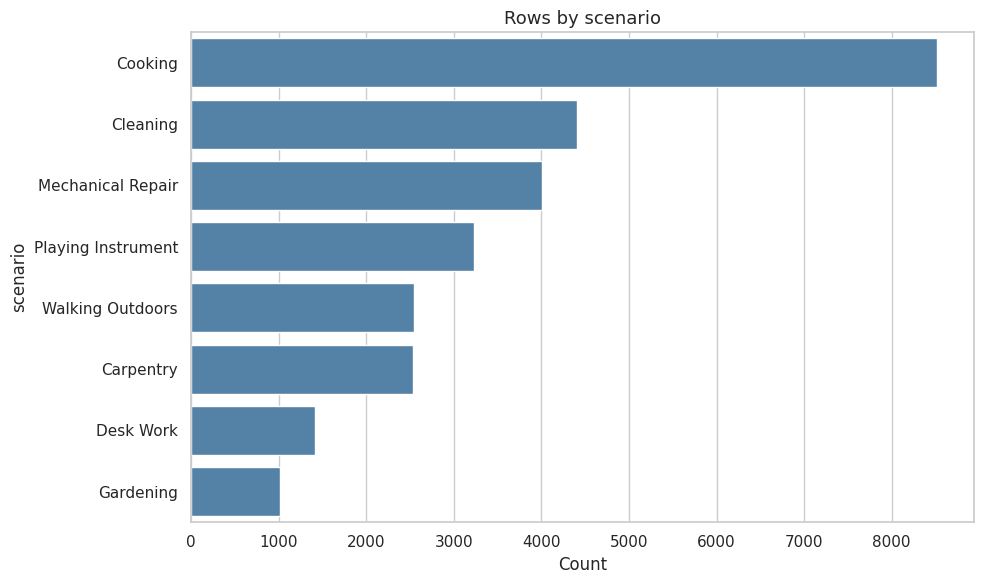

,percent_of_rows
scenario,
Cooking,30.78
Cleaning,15.94
Mechanical Repair,14.50
Playing Instrument,11.66
Walking Outdoors,9.21
Carpentry,9.15
Desk Work,5.10
Gardening,3.66


In [7]:
sc_order = df["scenario"].value_counts().index
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, y="scenario", order=sc_order, color="steelblue", ax=ax)
ax.set_title("Rows by scenario")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

display((df["scenario"].value_counts(normalize=True) * 100).round(2).to_frame("percent_of_rows"))


/tmp/ipykernel_1448991/3415682403.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="action", order=act_order, palette="viridis", ax=axes[0])


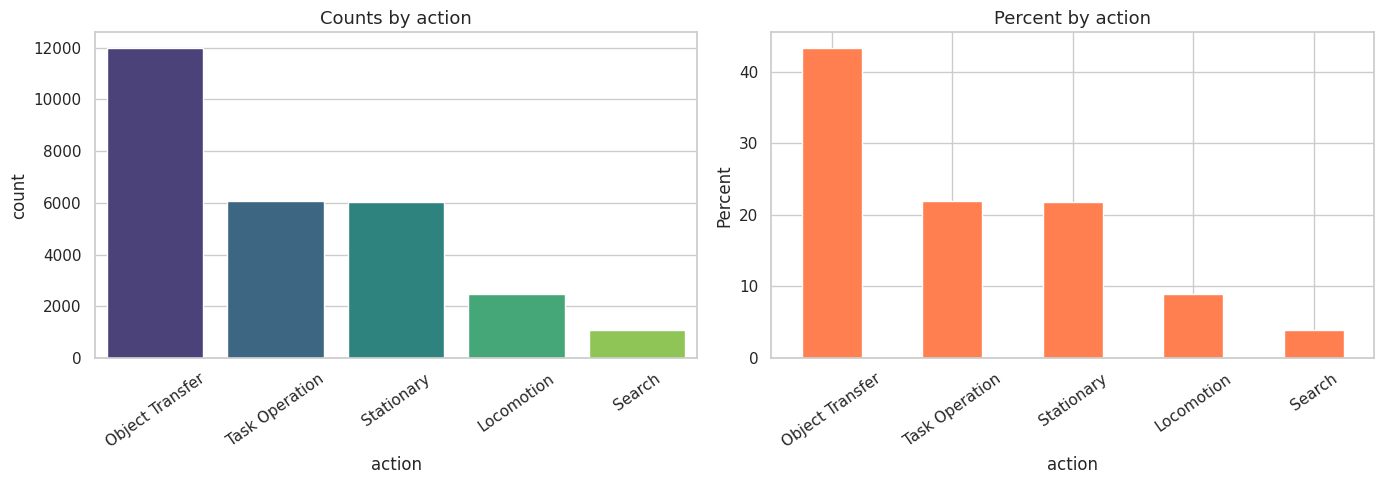

In [8]:
act_order = df["action"].value_counts().index
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="action", order=act_order, palette="viridis", ax=axes[0])
axes[0].set_title("Counts by action")
axes[0].tick_params(axis="x", rotation=35)

(df["action"].value_counts(normalize=True).reindex(act_order) * 100).plot(
    kind="bar", color="coral", ax=axes[1]
)
axes[1].set_title("Percent by action")
axes[1].set_ylabel("Percent")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()


### Camembert (pie) charts — class proportions

Same logic as the bar plots above, but from **whichever file you set** as `PIE_DATA_PATH` in the next cell (must include `scenario` and `action`). Each wedge is the **fraction of rows** in that class; slice labels only if share **≥ 3%**.



Camembert data: /shared/ssd_14T/home/leopolddas/HAR_Lab_Initiative_AI/data/annotation_rounds/final_gold_dataset/HAR_dataset_for_stats.csv (27,657 rows)


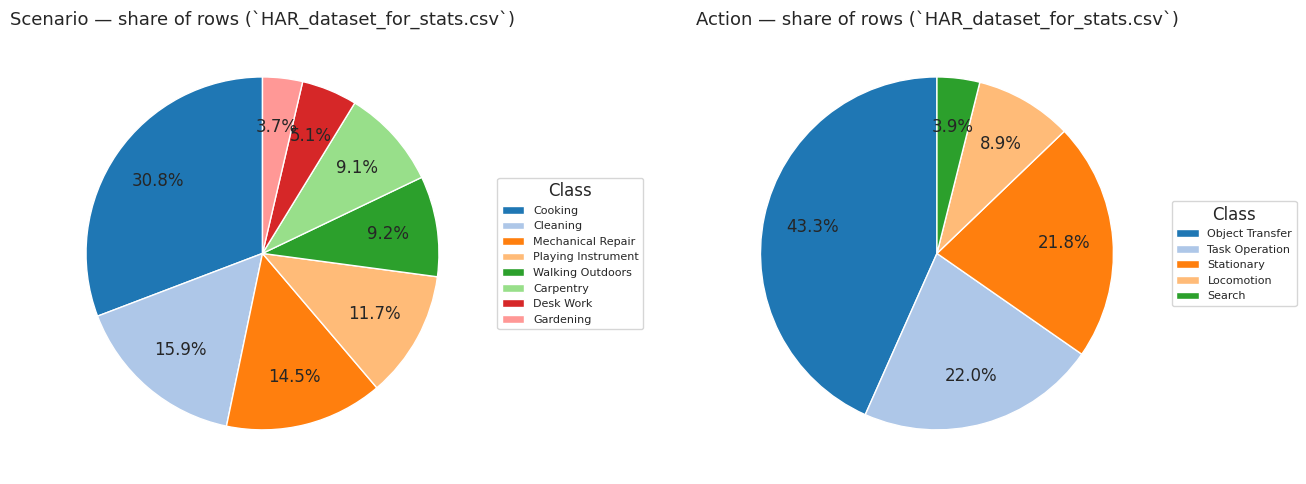

scenario value_counts:


scenario
Cooking               8514
Cleaning              4409
Mechanical Repair     4009
Playing Instrument    3226
Walking Outdoors      2547
Carpentry             2530
Desk Work             1410
Gardening             1012
Name: count, dtype: int64

action value_counts:


action
Object Transfer    11987
Task Operation      6080
Stationary          6041
Locomotion          2468
Search              1081
Name: count, dtype: int64

In [4]:
# Camembert (scenario + action) — set PIE_DATA_PATH to any CSV that has `scenario` and `action` columns
PIE_DATA_PATH = ROOT / "data/annotation_rounds/final_gold_dataset/HAR_dataset_for_stats.csv"
# Examples (pick one path):
# PIE_DATA_PATH = ROOT / "data/annotation_rounds/final_gold_dataset/HAR_dataset_155.csv"
# PIE_DATA_PATH = ROOT / "data/labels/action_labels_llm_clean_refined.csv"

df_pies = pd.read_csv(PIE_DATA_PATH)
assert {"scenario", "action"}.issubset(df_pies.columns), "CSV needs columns: scenario, action"
print(f"Camembert data: {PIE_DATA_PATH} ({len(df_pies):,} rows)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
camembert_chart(
    df_pies["scenario"],
    axes[0],
    f"Scenario — share of rows (`{PIE_DATA_PATH.name}`)",
)
camembert_chart(df_pies["action"], axes[1], f"Action — share of rows (`{PIE_DATA_PATH.name}`)")
plt.tight_layout()
plt.show()

print("scenario value_counts:")
display(df_pies["scenario"].value_counts())
print("action value_counts:")
display(df_pies["action"].value_counts())



Camembert data: /shared/ssd_14T/home/leopolddas/HAR_Lab_Initiative_AI/data/labels/action_labels_llm_clean_refined.csv (355,580 rows)


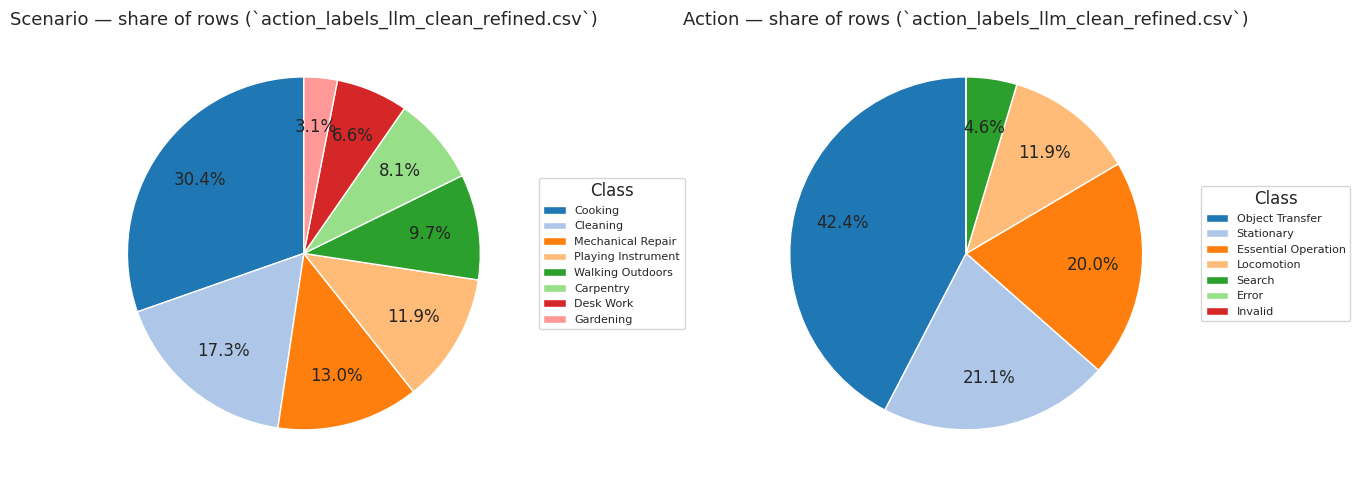

scenario value_counts:


scenario
Cooking               108000
Cleaning               61421
Mechanical Repair      46298
Playing Instrument     42417
Walking Outdoors       34415
Carpentry              28720
Desk Work              23457
Gardening              10852
Name: count, dtype: int64

action value_counts:


action
Object Transfer        150700
Stationary              75089
Essential Operation     71023
Locomotion              42275
Search                  16485
Error                       6
Invalid                     2
Name: count, dtype: int64

In [5]:
# Camembert (scenario + action) — set PIE_DATA_PATH to any CSV that has `scenario` and `action` columns
PIE_DATA_PATH = ROOT / "data/labels/action_labels_llm_clean_refined.csv"
# Examples (pick one path):
# PIE_DATA_PATH = ROOT / "data/annotation_rounds/final_gold_dataset/HAR_dataset_155.csv"
# PIE_DATA_PATH = ROOT / "data/labels/action_labels_llm_clean_refined.csv"

df_pies = pd.read_csv(PIE_DATA_PATH)
assert {"scenario", "action"}.issubset(df_pies.columns), "CSV needs columns: scenario, action"
print(f"Camembert data: {PIE_DATA_PATH} ({len(df_pies):,} rows)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
camembert_chart(
    df_pies["scenario"],
    axes[0],
    f"Scenario — share of rows (`{PIE_DATA_PATH.name}`)",
)
camembert_chart(df_pies["action"], axes[1], f"Action — share of rows (`{PIE_DATA_PATH.name}`)")
plt.tight_layout()
plt.show()

print("scenario value_counts:")
display(df_pies["scenario"].value_counts())
print("action value_counts:")
display(df_pies["action"].value_counts())



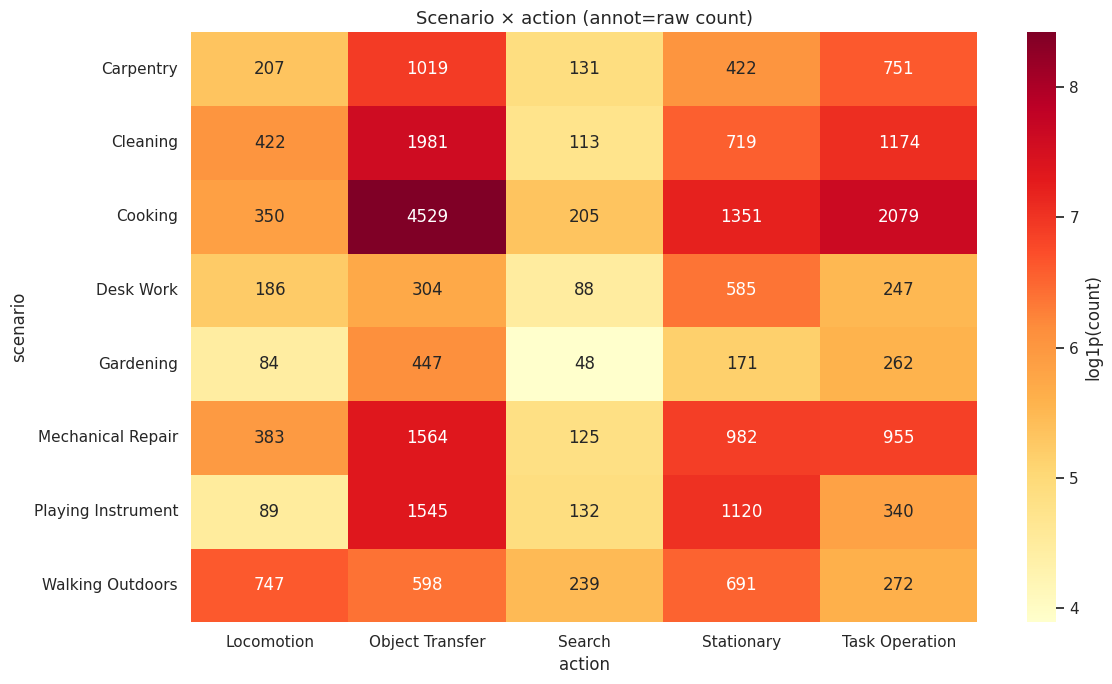

In [10]:
ct = pd.crosstab(df["scenario"], df["action"])
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(np.log1p(ct), annot=ct.values, fmt="d", cmap="YlOrRd", cbar_kws={"label": "log1p(count)"}, ax=ax)
ax.set_title("Scenario × action (annot=raw count)")
plt.tight_layout()
plt.show()


## 3) Corrections (`action` -> `corrected_action`)

Rows with correction: 4,100 (14.82% of dataset)


,count,percent_of_corrections
pair,,
Stationary -> Task Operation,999,24.37
Object Transfer -> Task Operation,615,15.00
Stationary -> Object Transfer,505,12.32
Locomotion -> Object Transfer,384,9.37
Task Operation -> Object Transfer,378,9.22
Object Transfer -> Stationary,198,4.83
Stationary -> Search,197,4.80
Task Operation -> Stationary,173,4.22
Locomotion -> Task Operation,153,3.73


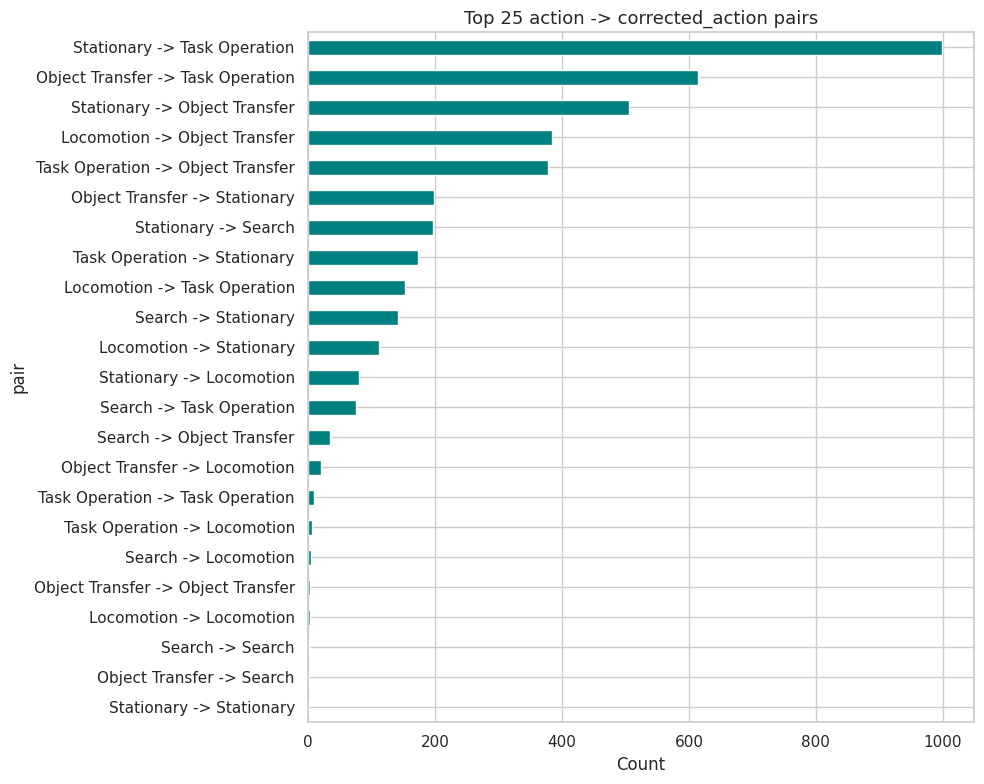

In [13]:
corr = df[df["corrected_action"].notna()].copy()
print(f"Rows with correction: {len(corr):,} ({100*len(corr)/len(df):.2f}% of dataset)")

corr["pair"] = corr["action"].astype(str) + " -> " + corr["corrected_action"].astype(str)
top_pairs = corr["pair"].value_counts().head(25)

display(pd.DataFrame({
    "count": top_pairs,
    "percent_of_corrections": (100 * top_pairs / top_pairs.sum()).round(2)
}))

fig, ax = plt.subplots(figsize=(10, 8))
top_pairs.sort_values().plot(kind="barh", color="teal", ax=ax)
ax.set_title("Top 25 action -> corrected_action pairs")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()


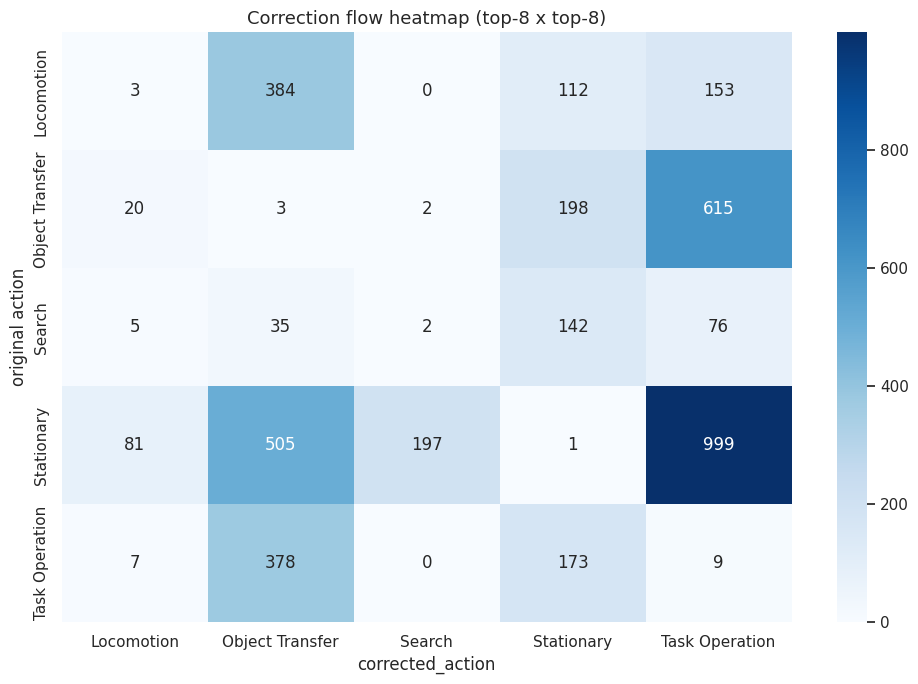

In [14]:
if len(corr):
    top_from = corr["action"].value_counts().head(8).index
    top_to = corr["corrected_action"].value_counts().head(8).index
    sub = corr[corr["action"].isin(top_from) & corr["corrected_action"].isin(top_to)]
    cm = pd.crosstab(sub["action"], sub["corrected_action"])

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title("Correction flow heatmap (top-8 x top-8)")
    ax.set_xlabel("corrected_action")
    ax.set_ylabel("original action")
    plt.tight_layout()
    plt.show()


## 4) Optional filters for stricter QA stats

In [15]:
# Example: keep only rows with explicit main status in {Gold, Bad}
strict = df[df["status_main"].isin(["Gold", "Bad"])].copy()
print(f"Strict subset rows: {len(strict):,} / {len(df):,}")
print(strict["status_main"].value_counts())


Strict subset rows: 27,657 / 27,657
status_main
Gold    24093
Bad      3564
Name: count, dtype: int64


## 5) Scenario-action dependency views (for hierarchical motivation)

These plots are designed to show **dependence** between scenario and action beyond raw counts.

- `P(action | scenario)`: each row sums to 1, so you see each scenario's action profile.
- `Lift = P(action | scenario) / P(action)`: values > 1 mean an action is overrepresented for that scenario.
- Statistical metrics: Mutual Information and Cramer's V quantify dependence strength.

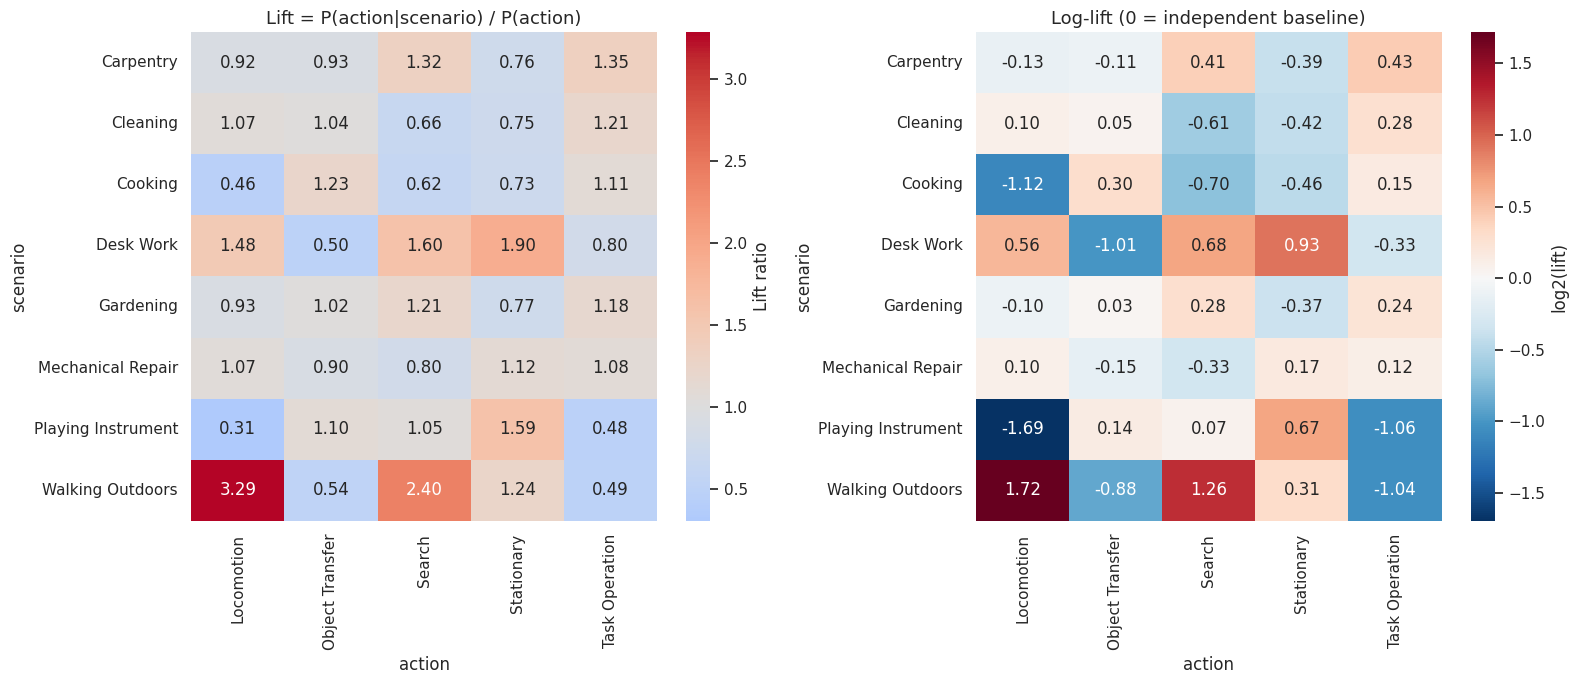

Interpretation:
 - Lift > 1 (log-lift > 0): action is more frequent in that scenario than globally.
 - Lift < 1 (log-lift < 0): action is underrepresented in that scenario.


In [17]:
# 5.2 Lift heatmap: P(action | scenario) / P(action)
# Self-contained so the cell works even if run before 5.1
ct = pd.crosstab(df['scenario'], df['action'])
row_probs = ct.div(ct.sum(axis=1), axis=0)
global_action_probs = ct.sum(axis=0) / ct.values.sum()
lift = row_probs.div(global_action_probs, axis=1)
log_lift = np.log2(lift)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(
    lift,
    annot=lift.round(2),
    fmt='.2f',
    cmap='coolwarm',
    center=1.0,
    ax=axes[0],
    cbar_kws={'label': 'Lift ratio'},
)
axes[0].set_title('Lift = P(action|scenario) / P(action)')
axes[0].set_xlabel('action')
axes[0].set_ylabel('scenario')

sns.heatmap(
    log_lift,
    annot=log_lift.round(2),
    fmt='.2f',
    cmap='RdBu_r',
    center=0.0,
    ax=axes[1],
    cbar_kws={'label': 'log2(lift)'},
)
axes[1].set_title('Log-lift (0 = independent baseline)')
axes[1].set_xlabel('action')
axes[1].set_ylabel('scenario')

plt.tight_layout()
plt.show()

print('Interpretation:')
print(' - Lift > 1 (log-lift > 0): action is more frequent in that scenario than globally.')
print(' - Lift < 1 (log-lift < 0): action is underrepresented in that scenario.')

In [18]:
from sklearn.metrics import mutual_info_score

# Mutual Information
mi = mutual_info_score(df['scenario'], df['action'])

# Cramer's V via chi-squared
try:
    from scipy.stats import chi2_contingency
    chi2, p_value, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    cramers_v = np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1))

    print(f'Mutual Information (scenario, action): {mi:.4f}')
    print(f'Chi2 p-value: {p_value:.3e}')
    print(f"Cramer's V: {cramers_v:.4f}")
except Exception as e:
    print(f'Mutual Information (scenario, action): {mi:.4f}')
    print('Could not compute Cramer\'s V (scipy unavailable or error).')
    print('Error:', e)

Mutual Information (scenario, action): 0.0626
Chi2 p-value: 0.000e+00
Cramer's V: 0.1850


## 6) IMU-based t-SNE on `HAR_dataset_155.csv`

We build **two separate** feature vectors per matched IMU window:
- **Accel** (slice `0:3`, three axes): mean, std, energy per axis + magnitude mean/std.
- **Gyro** (slice `3:6`): same structure.

Then we run **two independent t-SNE** embeddings (accel space vs gyro space) and plot **four** figures:
1. Accel t-SNE × action
2. Accel t-SNE × scenario
3. Gyro t-SNE × action
4. Gyro t-SNE × scenario

Optional cells below: same embeddings colored by **split** (train/val/test) to spot domain shift.

Interpretation: t-SNE is qualitative; overlapping blobs often mean simple window stats do not separate classes (then try model embeddings from a trained encoder).



In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

ROOT = Path("..").resolve()
TSNE_DATA_PATH = ROOT / "data/annotation_rounds/final_gold_dataset/HAR_dataset_155.csv"
PROCESSED_DIR = ROOT / "data/processed_ego4d"

df155 = pd.read_csv(TSNE_DATA_PATH)
print(f"Total rows in HAR_dataset_155: {len(df155):,}")
print(df155[['split', 'scenario', 'action']].head(2))


Total rows in HAR_dataset_155: 153,158
   split  scenario           action
0  train  Cleaning  Object Transfer
1  train  Cleaning  Object Transfer


_Camembert charts for arbitrary CSVs are in **§2** (set `PIE_DATA_PATH`). They are not repeated here so Section 6 stays focused on IMU t-SNE._


In [2]:
# Adjustable parameters
N_SAMPLE = 8000            # lower if runtime is high (e.g., 4000)
RANDOM_STATE = 42
TSNE_PERPLEXITY = 35

# Stratify by action to keep class balance in visualization
sampled = (
    df155.dropna(subset=['video_uid', 'timestamp_sec', 'action', 'scenario'])
    .groupby('action', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), max(200, N_SAMPLE // max(df155['action'].nunique(), 1))), random_state=RANDOM_STATE))
)
if len(sampled) > N_SAMPLE:
    sampled = sampled.sample(N_SAMPLE, random_state=RANDOM_STATE)
sampled = sampled.reset_index(drop=True)

print(f"Rows requested for t-SNE: {len(sampled):,}")


def features_accel(window):
    """Accel only: channels 0:3. Shape (T, C) with C >= 6."""
    accel = window[:, :3]
    a_mean = accel.mean(axis=0)
    a_std = accel.std(axis=0)
    a_energy = (accel ** 2).mean(axis=0)
    a_mag = np.linalg.norm(accel, axis=1)
    return np.concatenate([a_mean, a_std, a_energy, [a_mag.mean()], [a_mag.std()]])


def features_gyro(window):
    """Gyro only: channels 3:6."""
    gyro = window[:, 3:6]
    g_mean = gyro.mean(axis=0)
    g_std = gyro.std(axis=0)
    g_energy = (gyro ** 2).mean(axis=0)
    g_mag = np.linalg.norm(gyro, axis=1)
    return np.concatenate([g_mean, g_std, g_energy, [g_mag.mean()], [g_mag.std()]])


rows_accel, rows_gyro, kept_indices = [], [], []
for i, row in sampled.iterrows():
    uid = row['video_uid']
    ts = float(row['timestamp_sec'])
    seq_path = PROCESSED_DIR / uid / 'seq.npz'
    if not seq_path.exists():
        continue
    try:
        data = np.load(seq_path)
        traj = data['traj']
        timestamps = data['timestamp']
        if len(traj) == 0 or traj.shape[-1] < 6:
            continue
        centers = timestamps.mean(axis=1)
        idx = int(np.argmin(np.abs(centers - ts)))
        window = traj[idx]
        if not np.isfinite(window).all():
            continue
        rows_accel.append(features_accel(window))
        rows_gyro.append(features_gyro(window))
        kept_indices.append(i)
    except Exception:
        continue

sampled_imu = sampled.iloc[kept_indices].copy().reset_index(drop=True)
X_accel = np.vstack(rows_accel)
X_gyro = np.vstack(rows_gyro)

print(f"Rows matched to IMU windows: {len(sampled_imu):,}")
print(f"Accel feature dim: {X_accel.shape[1]}, Gyro feature dim: {X_gyro.shape[1]}")

n = len(sampled_imu)
perp = min(TSNE_PERPLEXITY, max(5, (n - 1) // 3))

X_accel_s = StandardScaler().fit_transform(X_accel)
X_gyro_s = StandardScaler().fit_transform(X_gyro)

tsne_accel = TSNE(
    n_components=2,
    perplexity=perp,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_STATE,
)
emb_accel = tsne_accel.fit_transform(X_accel_s)

tsne_gyro = TSNE(
    n_components=2,
    perplexity=perp,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_STATE,
)
emb_gyro = tsne_gyro.fit_transform(X_gyro_s)

sampled_imu['tsne_accel_x'] = emb_accel[:, 0]
sampled_imu['tsne_accel_y'] = emb_accel[:, 1]
sampled_imu['tsne_gyro_x'] = emb_gyro[:, 0]
sampled_imu['tsne_gyro_y'] = emb_gyro[:, 1]
sampled_imu.head(3)



Rows requested for t-SNE: 8,000


/tmp/ipykernel_1448991/2418199741.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), max(200, N_SAMPLE // max(df155['action'].nunique(), 1))), random_state=RANDOM_STATE))


Rows matched to IMU windows: 7,815
Accel feature dim: 11, Gyro feature dim: 11


,video_uid,timestamp_sec,narration_text,scenario,action,source,confidence,action_id,split,tsne_accel_x,tsne_accel_y,tsne_gyro_x,tsne_gyro_y
0,fd344164-fa5f-4ce1-bf0c-40319056cc32,1646.904430,#C C walks,Walking Outdoors,Locomotion,propagated,1.0,3,test,-2.227553,17.811407,38.135971,15.833049
1,0928af96-a3fd-4930-9bc1-2fa43d01bb53,194.046759,#C C moves around,Gardening,Locomotion,propagated,1.0,3,test,-2.009595,56.808014,-23.866899,11.449631
2,652f0590-aab5-4de1-b578-238adb54fa0e,3744.744619,#C C walks around,Mechanical Repair,Locomotion,propagated,1.0,3,train,-18.098951,54.958553,55.160759,-21.350548


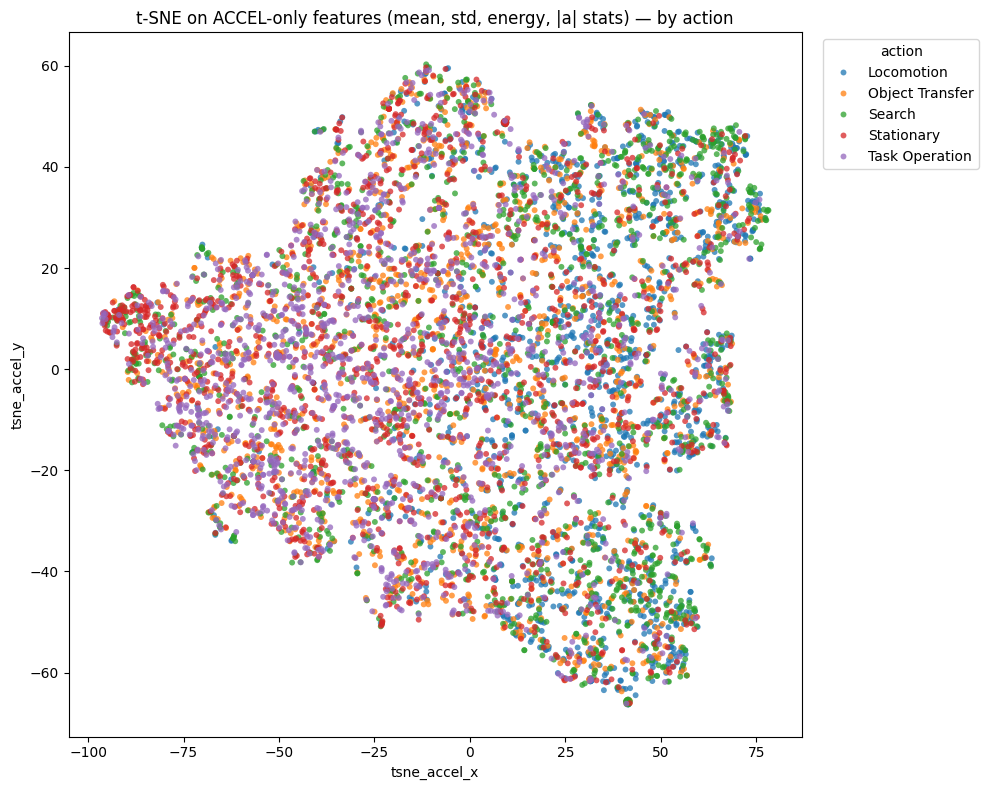

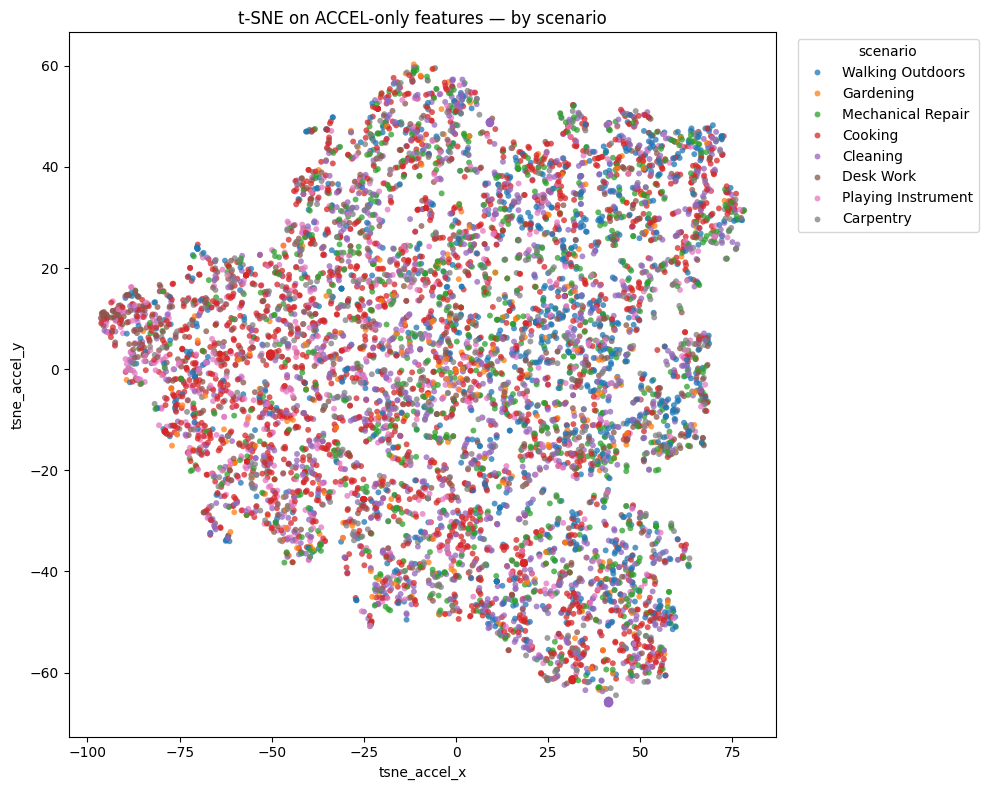

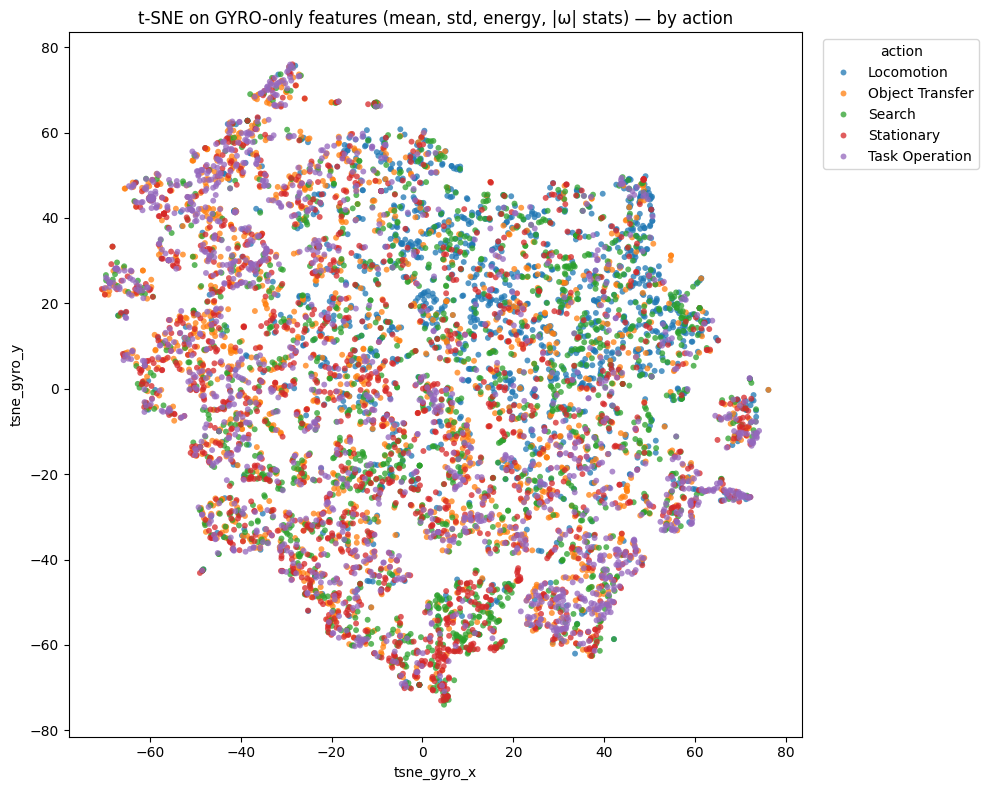

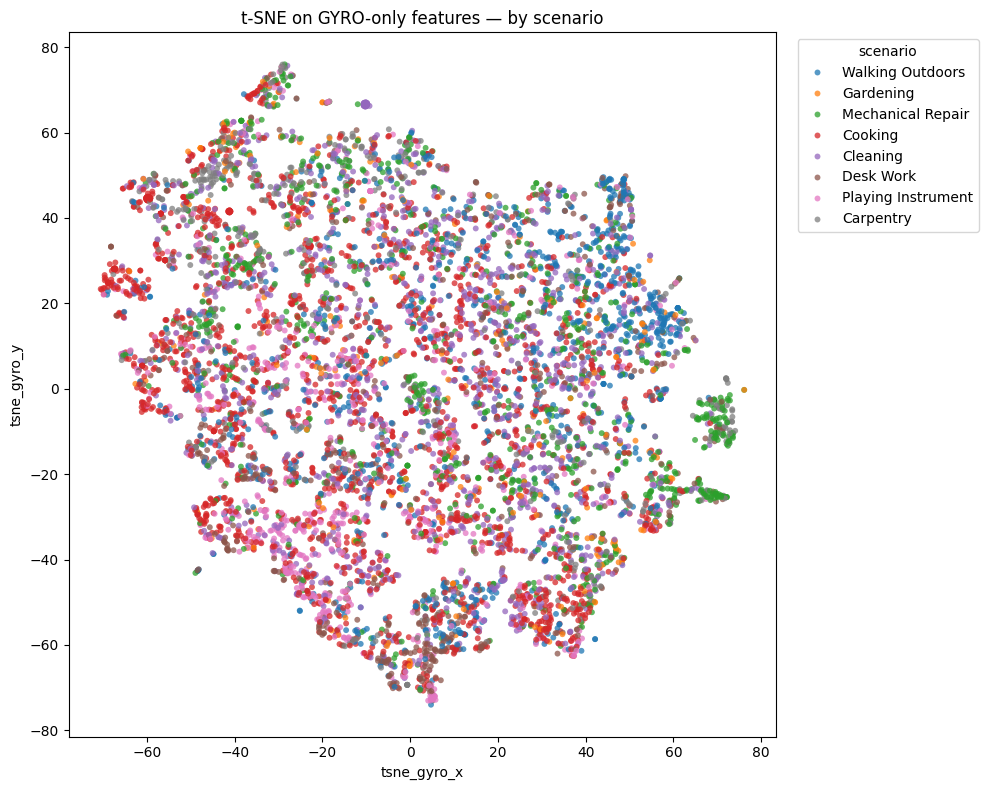

In [3]:
# Four separate t-SNE views: Accel vs Gyro × Action vs Scenario
# (Two independent t-SNE fits — accel and gyro live in different feature spaces.)

def plot_tsne(xcol, ycol, hue, title):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=sampled_imu,
        x=xcol,
        y=ycol,
        hue=hue,
        s=18,
        alpha=0.75,
        linewidth=0,
    )
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title=hue)
    plt.tight_layout()
    plt.show()

plot_tsne('tsne_accel_x', 'tsne_accel_y', 'action',
          't-SNE on ACCEL-only features (mean, std, energy, |a| stats) — by action')
plot_tsne('tsne_accel_x', 'tsne_accel_y', 'scenario',
          't-SNE on ACCEL-only features — by scenario')
plot_tsne('tsne_gyro_x', 'tsne_gyro_y', 'action',
          't-SNE on GYRO-only features (mean, std, energy, |ω| stats) — by action')
plot_tsne('tsne_gyro_x', 'tsne_gyro_y', 'scenario',
          't-SNE on GYRO-only features — by scenario')



### Optional: same embedding, colored by split

If train/val/test form separate blobs, you may have a **distribution shift** problem (not just class separation).



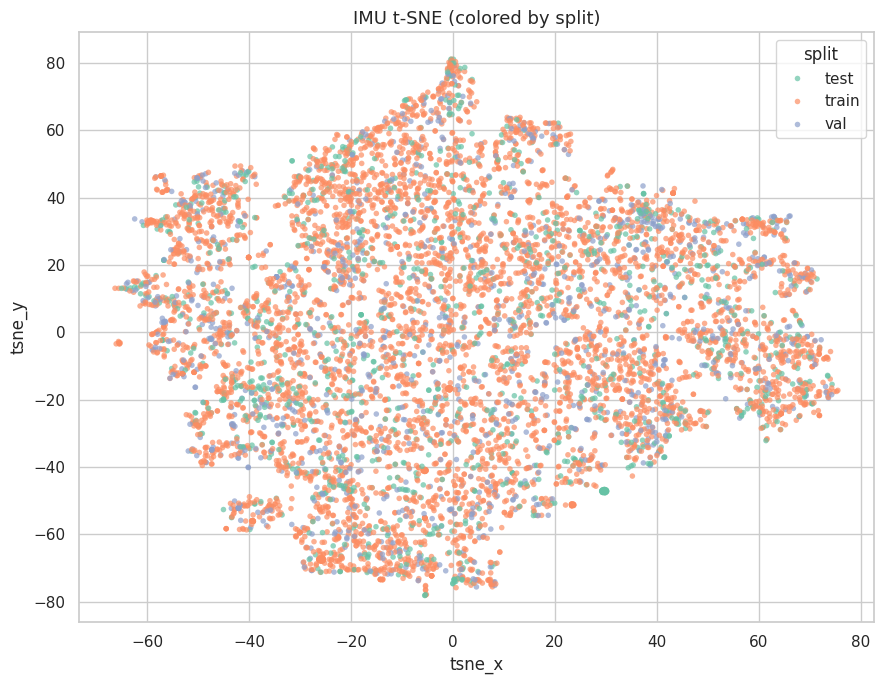

In [33]:
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=sampled_imu,
    x='tsne_accel_x',
    y='tsne_accel_y',
    hue='split',
    s=16,
    alpha=0.7,
    linewidth=0,
    palette='Set2',
)
plt.title('Accel t-SNE colored by split (diagnostic)')
plt.legend(title='split')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=sampled_imu,
    x='tsne_gyro_x',
    y='tsne_gyro_y',
    hue='split',
    s=16,
    alpha=0.7,
    linewidth=0,
    palette='Set2',
)
plt.title('Gyro t-SNE colored by split (diagnostic)')
plt.legend(title='split')
plt.tight_layout()
plt.show()



## Paper dataset section: LaTeX tables

Tables for the dataset write-up: full LLM five-class distribution, scenario distribution over those rows, Round 1 merged verdict counts, refined r001+r002 verdict summary, semantic-to-motion map, gold train/val/test action counts.

Run the next cell. It runs `scripts/generate_paper_tables_tex.py`, prints LaTeX below, and writes `doc/generated_paper_tables.tex` (use `\input{generated_paper_tables}` from `doc/` or adjust path from your master file).


In [6]:
# Paper LaTeX tables -> doc/generated_paper_tables.tex
# Logic lives in scripts/generate_paper_tables_tex.py (easier to maintain than a huge notebook cell).
import runpy
from pathlib import Path

ROOT = Path("..").resolve() if (Path("..") / "scripts").exists() else Path(".").resolve()
runpy.run_path(str(ROOT / "scripts" / "generate_paper_tables_tex.py"), run_name="__main__")


% Auto-generated by notebooks/annotation_rounds_analysis.ipynb
% Do not edit by hand; regenerate from the notebook.

% --- tab:action_dist_llm_full ---
\begin{table}[ht]
\centering
\small
\caption{Action distribution, full LLM-labeled corpus (five primary classes).}
\label{tab:action_dist_llm_full}
\begin{tabular}{lrr}
\toprule
Class & Count & \% \
\midrule
Object Transfer & 150{,}700 & 42.4\% \\
Essential Operation & 71{,}023 & 20.0\% \\
Stationary & 75{,}089 & 21.1\% \\
Locomotion & 42{,}275 & 11.9\% \\
Search & 16{,}485 & 4.6\% \\
\midrule
Total & 355{,}572 & 100.0\\% \\
\bottomrule
\end{tabular}
\end{table}

% --- tab:scenario_dist (LLM-labeled windows, five-class rows only) ---
\begin{table}[ht]
\centering
\small
\caption{Scenario distribution: unique videos and narration windows in the LLM-labeled subset.}
\label{tab:scenario_dist}
\begin{tabular}{lrrr}
\toprule
Scenario & Videos & Narrations & \% \
\midrule
Cooking & 230 & 108{,}000 & 30.4\% \\
Cleaning & 279 & 61{,}421 & 17.3\%

## Paper figures (for screenshots)

Run the next cell to get inline plots. The same figures are written to `doc/paper_figure_exports/` at 200 dpi: `fig_llm_five_class_counts.png`, `fig_scenario_window_counts.png`, `fig_r1_verdict_pie.png`, `fig_refined_verdicts_by_round.png`, `fig_gold_splits_stacked.png`, `fig_gold_motion_mapped.png`.

### Model / thesis tables (manual entry)

The cell after that reproduces **beta sweep** curves, **main results** (Table 2–style bars), and **two separate figures** for model comparison: `fig_model_efficiency.png` (log-scaled params vs combined F1) and `fig_pareto_baselines.png` (broken x-axis Pareto view). Values are defined in-code so you can edit them if numbers change.

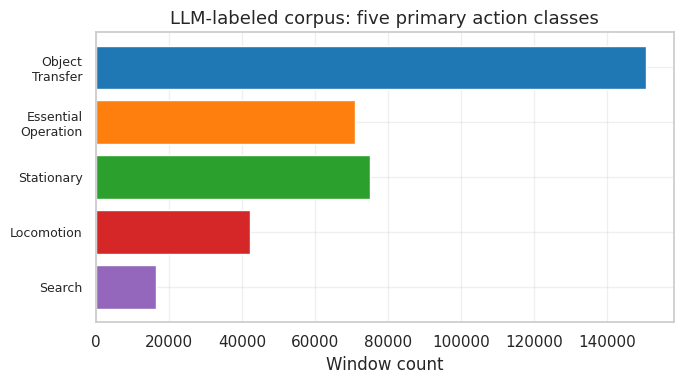

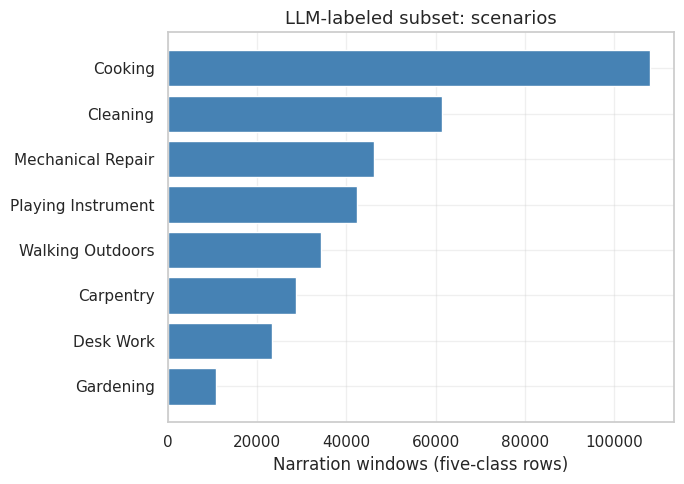

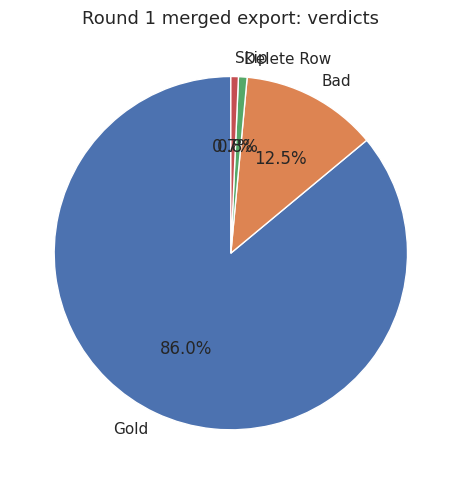

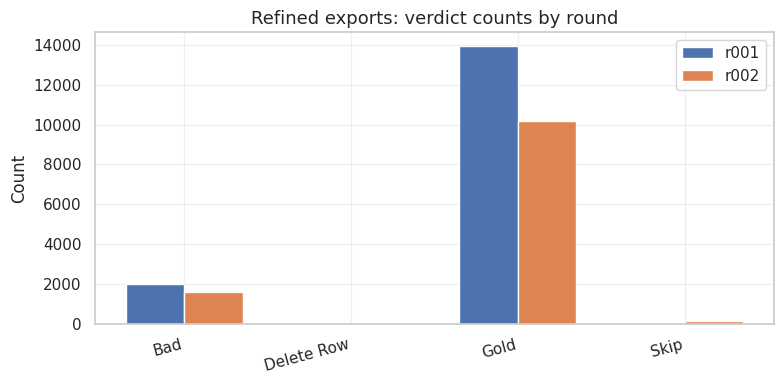

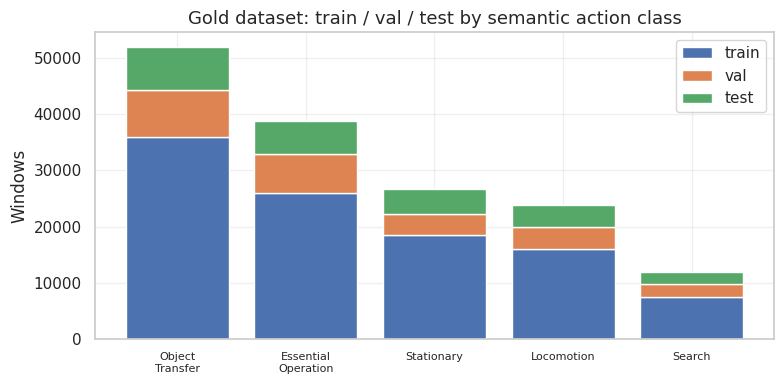

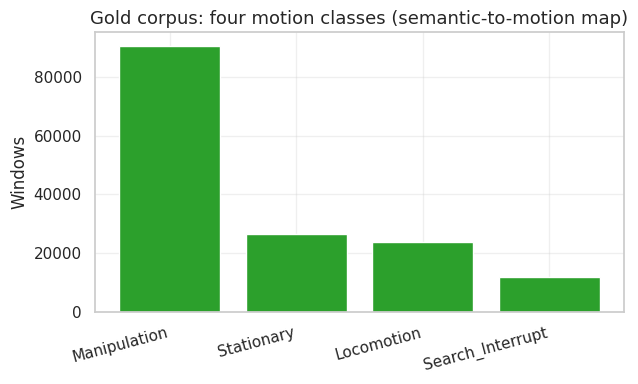

Saved figures under /shared/ssd_14T/home/leopolddas/HAR_Lab_Initiative_AI/doc/paper_figure_exports


In [10]:
# Paper-ready plots (run from notebooks/ so ROOT points at repo)
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..").resolve() if (Path("..") / "data").exists() else Path(".").resolve()
OUT = ROOT / "doc" / "paper_figure_exports"
OUT.mkdir(parents=True, exist_ok=True)

LLM_CSV = ROOT / "data" / "labels" / "action_labels_llm_clean_refined.csv"
R001_MERGED = ROOT / "data" / "annotation_rounds" / "r001_merged_validation" / "round1_validated_rows_with_decisions.csv"
R001_REFINED = ROOT / "data" / "annotation_rounds" / "r001_gold_exports" / "r001_refined_combined" / "r001_refined_combined.csv"
R002_REFINED = ROOT / "data" / "annotation_rounds" / "r002_gold_exports" / "r002_refined_combined" / "r002_refined_combined.csv"
GOLD_TRAIN = ROOT / "data" / "annotation_rounds" / "final_gold_dataset" / "train.csv"
GOLD_VAL = ROOT / "data" / "annotation_rounds" / "final_gold_dataset" / "val.csv"
GOLD_TEST = ROOT / "data" / "annotation_rounds" / "final_gold_dataset" / "test.csv"

PRIMARY_CLASSES = [
    "Object Transfer",
    "Essential Operation",
    "Stationary",
    "Locomotion",
    "Search",
]

plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

# --- Load LLM subset (five primary classes) ---
df_llm = pd.read_csv(LLM_CSV, usecols=["scenario", "action", "video_uid"])
mask5 = df_llm["action"].isin(PRIMARY_CLASSES)
df5 = df_llm.loc[mask5]
vc_action = df5["action"].value_counts().reindex(PRIMARY_CLASSES).fillna(0).astype(int)

# 1) LLM five-class distribution
fig, ax = plt.subplots(figsize=(7, 4))
y = np.arange(len(PRIMARY_CLASSES))
ax.barh(y, vc_action.values, color=plt.cm.tab10(np.linspace(0, 0.45, len(y))))
ax.set_yticks(y, [c.replace(" ", "\n") for c in PRIMARY_CLASSES], fontsize=9)
ax.set_xlabel("Window count")
ax.set_title("LLM-labeled corpus: five primary action classes")
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(OUT / "fig_llm_five_class_counts.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) Scenario distribution (narration windows)
scen = df5.groupby("scenario").size().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(scen.index.astype(str), scen.values, color="steelblue")
ax.set_xlabel("Narration windows (five-class rows)")
ax.set_title("LLM-labeled subset: scenarios")
plt.tight_layout()
fig.savefig(OUT / "fig_scenario_window_counts.png", dpi=200, bbox_inches="tight")
plt.show()

# 3) Round 1 merged verdicts
if R001_MERGED.is_file():
    r1 = pd.read_csv(R001_MERGED, usecols=["validated_final_verdict"])
    vc1 = r1["validated_final_verdict"].value_counts()
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie(vc1.values, labels=vc1.index, autopct="%1.1f%%", startangle=90)
    ax.set_title("Round 1 merged export: verdicts")
    plt.tight_layout()
    fig.savefig(OUT / "fig_r1_verdict_pie.png", dpi=200, bbox_inches="tight")
    plt.show()

# 4) Refined r001 + r002 verdict counts (grouped bars)
rows = []
if R001_REFINED.is_file():
    a = pd.read_csv(R001_REFINED, usecols=["status_main"])
    rows.append(("r001", a["status_main"].value_counts()))
if R002_REFINED.is_file():
    b = pd.read_csv(R002_REFINED, usecols=["verdict"])
    rows.append(("r002", b["verdict"].value_counts()))
if rows:
    allv = sorted({v for _, s in rows for v in s.index})
    x = np.arange(len(allv))
    width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4))
    for i, (label, s) in enumerate(rows):
        vals = [int(s.get(v, 0)) for v in allv]
        ax.bar(x + (i - 0.5) * width, vals, width, label=label)
    ax.set_xticks(x, allv, rotation=15, ha="right")
    ax.set_ylabel("Count")
    ax.legend()
    ax.set_title("Refined exports: verdict counts by round")
    plt.tight_layout()
    fig.savefig(OUT / "fig_refined_verdicts_by_round.png", dpi=200, bbox_inches="tight")
    plt.show()

# 5) Gold splits: stacked train / val / test per action class
tr = pd.read_csv(GOLD_TRAIN, usecols=["action"])
va = pd.read_csv(GOLD_VAL, usecols=["action"])
te = pd.read_csv(GOLD_TEST, usecols=["action"])
bt = np.array([(tr["action"] == c).sum() for c in PRIMARY_CLASSES], dtype=float)
bv = np.array([(va["action"] == c).sum() for c in PRIMARY_CLASSES], dtype=float)
bu = np.array([(te["action"] == c).sum() for c in PRIMARY_CLASSES], dtype=float)
x = np.arange(len(PRIMARY_CLASSES))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, bt, label="train", color="#4C72B0")
ax.bar(x, bv, bottom=bt, label="val", color="#DD8452")
ax.bar(x, bu, bottom=bt + bv, label="test", color="#55A868")
ax.set_xticks(x, [c.replace(" ", "\n") for c in PRIMARY_CLASSES], fontsize=8)
ax.set_ylabel("Windows")
ax.legend()
ax.set_title("Gold dataset: train / val / test by semantic action class")
plt.tight_layout()
fig.savefig(OUT / "fig_gold_splits_stacked.png", dpi=200, bbox_inches="tight")
plt.show()

# 6) Gold corpus mapped to four motion classes
motion_map = {
    "Object Transfer": "Manipulation",
    "Essential Operation": "Manipulation",
    "Stationary": "Stationary",
    "Locomotion": "Locomotion",
    "Search": "Search_Interrupt",
}
allg = pd.concat([tr["action"], va["action"], te["action"]], ignore_index=True).map(motion_map)
vc_motion = allg.value_counts()
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(vc_motion.index.astype(str), vc_motion.values, color="#2ca02c")
ax.set_ylabel("Windows")
ax.set_title("Gold corpus: four motion classes (semantic-to-motion map)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
fig.savefig(OUT / "fig_gold_motion_mapped.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved figures under", OUT)


,beta,val_action_f1,val_scenario_f1,test_action_f1,test_scenario_f1,test_act_acc,test_scen_acc,best_epoch
0,0.0,0.436,0.139,0.466,0.121,0.4996,0.1507,10
1,0.3,0.432,0.609,0.457,0.569,0.4891,0.6010,17
2,0.5,0.425,0.607,0.453,0.570,NaN,NaN,22
3,0.7,0.421,0.611,0.451,0.572,0.4868,0.6004,38
4,1.0,0.164,0.603,0.157,0.562,NaN,NaN,18
5,Learnable→0,0.433,0.564,0.459,0.513,0.4937,0.5567,11
6,Per-class→0,0.433,0.568,0.461,0.519,0.4945,0.5613,10


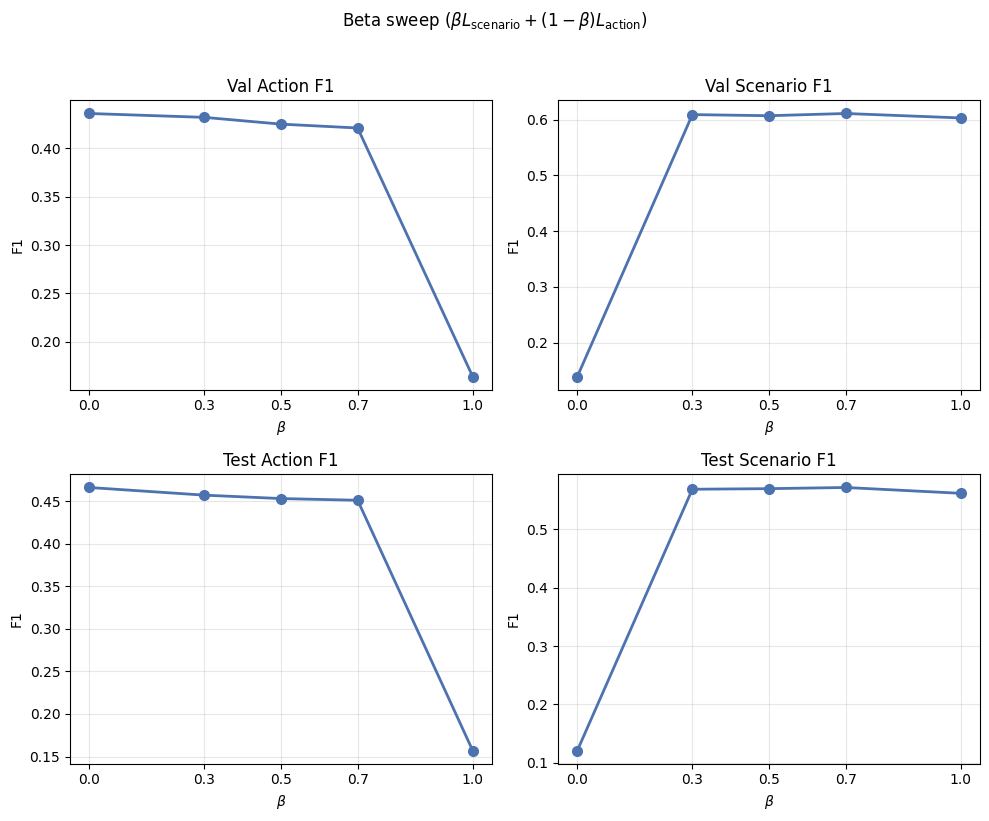

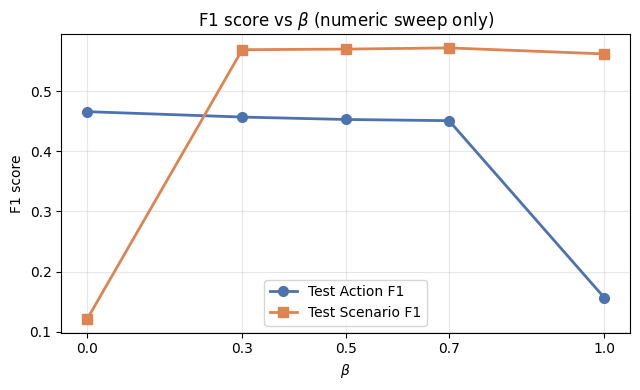

,model,act_f1,act_acc,scen_f1,scen_acc,params
0,MLP-MLP,0.339,0.436,0.528,0.578,1030000.0
1,Mantis-8M frozen,0.301,0.321,NaN,NaN,8000000.0
2,IMU2CLIP,0.385,0.435,0.559,0.590,4000000.0
3,Mantis-8M fine-tuned,0.370,0.467,NaN,NaN,8000000.0
4,CNN-MLP,0.367,0.451,0.523,0.554,1070000.0
5,CNN-LSTM-GRU,0.378,0.455,0.508,0.551,1190000.0
6,HiT-HAR (ours),0.457,0.490,0.587,0.610,703000.0


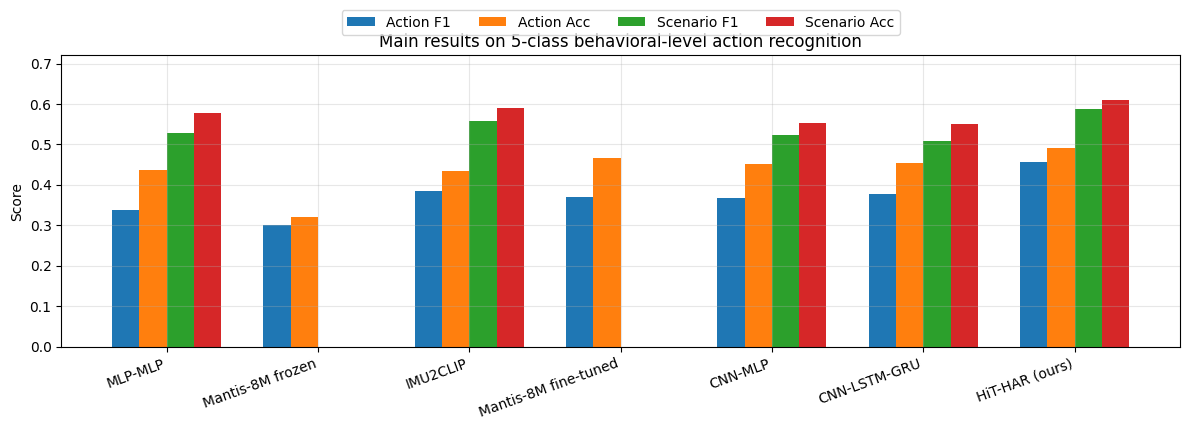

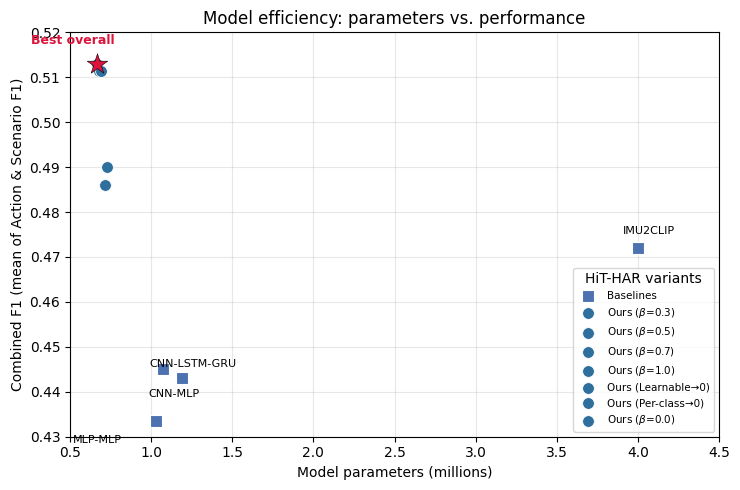

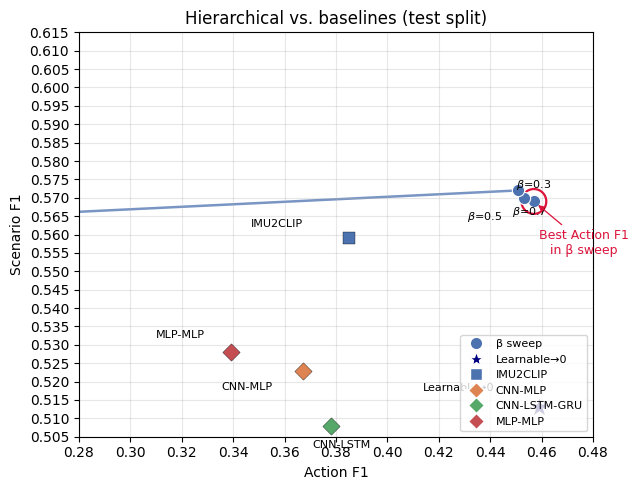

Saved: /shared/ssd_14T/home/leopolddas/HAR_Lab_Initiative_AI/doc/paper_figure_exports/fig_beta_sweep_f1_curves.png
Saved: /shared/ssd_14T/home/leopolddas/HAR_Lab_Initiative_AI/doc/paper_figure_exports/fig_beta_sweep_test_f1_dual.png
Saved: /shared/ssd_14T/home/leopolddas/HAR_Lab_Initiative_AI/doc/paper_figure_exports/fig_main_results_grouped_bars.png
Saved: /shared/ssd_14T/home/leopolddas/HAR_Lab_Initiative_AI/doc/paper_figure_exports/fig_model_efficiency.png
Saved: /shared/ssd_14T/home/leopolddas/HAR_Lab_Initiative_AI/doc/paper_figure_exports/fig_pareto_baselines.png


In [51]:
# Thesis model figures: beta sweep, main results bars, efficiency + Pareto (values from your tables)
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..").resolve() if (Path("..") / "data").exists() else Path(".").resolve()
OUT = ROOT / "doc" / "paper_figure_exports"
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "figure.dpi": 100,
    }
)

# --- Beta sweep (unified loss: β L_scen + (1-β) L_act) — pasted from your table ---
beta_sweep = pd.DataFrame(
    [
        ["0.0", 0.436, 0.139, 0.466, 0.121, 0.4996, 0.1507, 10],
        ["0.3", 0.432, 0.609, 0.457, 0.569, 0.4891, 0.6010, 17],
        ["0.5", 0.425, 0.607, 0.453, 0.570, np.nan, np.nan, 22],
        ["0.7", 0.421, 0.611, 0.451, 0.572, 0.4868, 0.6004, 38],
        ["1.0", 0.164, 0.603, 0.157, 0.562, np.nan, np.nan, 18],
        ["Learnable→0", 0.433, 0.564, 0.459, 0.513, 0.4937, 0.5567, 11],
        ["Per-class→0", 0.433, 0.568, 0.461, 0.519, 0.4945, 0.5613, 10],
    ],
    columns=[
        "beta",
        "val_action_f1",
        "val_scenario_f1",
        "test_action_f1",
        "test_scenario_f1",
        "test_act_acc",
        "test_scen_acc",
        "best_epoch",
    ],
)
display(beta_sweep)

numeric_mask = beta_sweep["beta"].isin(["0.0", "0.3", "0.5", "0.7", "1.0"])
bnum = beta_sweep.loc[numeric_mask].copy()
bnum["beta_f"] = bnum["beta"].astype(float)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax_va, ax_vs, ax_ta, ax_ts = axes.ravel()
for ax, col, title in [
    (ax_va, "val_action_f1", "Val Action F1"),
    (ax_vs, "val_scenario_f1", "Val Scenario F1"),
    (ax_ta, "test_action_f1", "Test Action F1"),
    (ax_ts, "test_scenario_f1", "Test Scenario F1"),
]:
    ax.plot(bnum["beta_f"], bnum[col], "o-", color="#4C72B0", lw=2, ms=7)
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel("F1")
    ax.set_title(title)
    ax.set_xticks(bnum["beta_f"])
fig.suptitle(r"Beta sweep ($\beta L_{\mathrm{scenario}} + (1-\beta) L_{\mathrm{action}}$)", y=1.02)
plt.tight_layout()
fig.savefig(OUT / "fig_beta_sweep_f1_curves.png", dpi=200, bbox_inches="tight")
plt.show()

# Test Action vs Scenario F1 vs numeric β (probe rows only in table above)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(bnum["beta_f"], bnum["test_action_f1"], "o-", label="Test Action F1", color="#4C72B0", lw=2, ms=7)
ax.plot(bnum["beta_f"], bnum["test_scenario_f1"], "s-", label="Test Scenario F1", color="#DD8452", lw=2, ms=7)
ax.set_xlabel(r"$\beta$")
ax.set_ylabel("F1 score")
ax.set_xticks(bnum["beta_f"])
ax.legend()
ax.set_title(r"F1 score vs $\beta$ (numeric sweep only)")
plt.tight_layout()
fig.savefig(OUT / "fig_beta_sweep_test_f1_dual.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Main results (Table 2: 5-class behavioral action) ---
main_results = pd.DataFrame(
    [
        ["MLP-MLP", 0.339, 0.436, 0.528, 0.578, 1.03e6],
        ["Mantis-8M frozen", 0.301, 0.321, np.nan, np.nan, 8e6],
        ["IMU2CLIP", 0.385, 0.435, 0.559, 0.590, 4.0e6],
        ["Mantis-8M fine-tuned", 0.370, 0.467, np.nan, np.nan, 8e6],
        ["CNN-MLP", 0.367, 0.451, 0.523, 0.554, 1.07e6],
        ["CNN-LSTM-GRU", 0.378, 0.455, 0.508, 0.551, 1.19e6],
        ["HiT-HAR (ours)", 0.457, 0.490, 0.587, 0.610, 703e3],
    ],
    columns=["model", "act_f1", "act_acc", "scen_f1", "scen_acc", "params"],
)
display(main_results)

metrics = ["act_f1", "act_acc", "scen_f1", "scen_acc"]
labels = ["Action F1", "Action Acc", "Scenario F1", "Scenario Acc"]
x = np.arange(len(main_results))
width = 0.18
fig, ax = plt.subplots(figsize=(12, 4.5))
for i, (m, lab) in enumerate(zip(metrics, labels)):
    vals = main_results[m].astype(float)
    ax.bar(x + (i - 1.5) * width, vals, width, label=lab)
ax.set_xticks(x, main_results["model"], rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 0.72)
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.18))
ax.set_title("Main results on 5-class behavioral-level action recognition")
plt.tight_layout()
fig.savefig(OUT / "fig_main_results_grouped_bars.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Combined F1 for efficiency plot: mean of macro Action F1 and Scenario F1 (same four F1/acc columns as table) ---
def combined_f1(act_f1, scen_f1):
    return (act_f1 + scen_f1) / 2


# Baselines: Table 2 (params in millions)
baselines = [
    ("MLP-MLP", 1.03, combined_f1(0.339, 0.528)),
    ("CNN-MLP", 1.07, combined_f1(0.367, 0.523)),
    ("CNN-LSTM-GRU", 1.19, combined_f1(0.378, 0.508)),
    ("IMU2CLIP", 4.0, combined_f1(0.385, 0.559)),
]
# Hierarchical variants: same param budget as HiT-HAR (703K); vertical spread = different β / probe (test F1)
params_hit_har_m = 0.703
hierarchical = [
    (r"Ours ($\beta$=0.3)", params_hit_har_m, combined_f1(0.457, 0.569)),
    (r"Ours ($\beta$=0.5)", params_hit_har_m, combined_f1(0.453, 0.570)),
    (r"Ours ($\beta$=0.7)", params_hit_har_m, combined_f1(0.451, 0.572)),
    (r"Ours ($\beta$=1.0)", params_hit_har_m, combined_f1(0.157, 0.562)),
    ("Ours (Learnable→0)", params_hit_har_m, combined_f1(0.459, 0.513)),
    ("Ours (Per-class→0)", params_hit_har_m, combined_f1(0.461, 0.519)),
    (r"Ours ($\beta$=0.0)", params_hit_har_m, combined_f1(0.466, 0.121)),
]
# Best overall = highest combined F1 among configs we plot (excluding collapsed β=0.0 scenario)
best_name, best_pm, best_c = max(
    [h for h in hierarchical if h[0] != r"Ours ($\beta$=0.0)"],
    key=lambda t: t[2],
)

try:
    from adjustText import adjust_text
except ImportError:
    adjust_text = None

from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# ----- Figure A: efficiency (linear scales like thesis figure) -----
fig1, ax_e = plt.subplots(figsize=(7.5, 5))
baseline_offsets = {
    "MLP-MLP": (-42, -14),
    "CNN-MLP": (8, -18),
    "CNN-LSTM-GRU": (8, 10),
    "IMU2CLIP": (8, 12),
}
for name, pm, cf in baselines:
    ax_e.scatter(pm, cf, s=85, marker="s", c="#4C72B0", zorder=3, edgecolors="white", linewidths=0.8)
    dx, dy = baseline_offsets.get(name, (8, 4))
    ax_e.annotate(
        name,
        (pm, cf),
        textcoords="offset points",
        xytext=(dx, dy),
        fontsize=8,
        ha="center",
        va="center",
    )
# Slight horizontal jitter (millions) so overlapping circles separate on linear axis
rng = np.linspace(-1.0, 1.0, len(hierarchical))
jitter_m = 0.035
for k, (name, pm, cf) in enumerate(hierarchical):
    pm_vis = pm + rng[k] * jitter_m
    ax_e.scatter(pm_vis, cf, s=72, marker="o", c="#2E6F9E", zorder=3, edgecolors="white", linewidths=0.6)
best_k = next(k for k, h in enumerate(hierarchical) if h[0] == best_name)
best_pm_vis = params_hit_har_m + rng[best_k] * jitter_m
ax_e.scatter([best_pm_vis], [best_c], s=240, marker="*", c="crimson", zorder=6, edgecolors="k", linewidths=0.4)
ax_e.annotate(
    "Best overall",
    (best_pm_vis, best_c),
    textcoords="offset points",
    xytext=(-48, 14),
    fontsize=9,
    color="crimson",
    fontweight="semibold",
)
handles_sq = ax_e.scatter([], [], s=85, marker="s", c="#4C72B0", label="Baselines", edgecolors="white", linewidths=0.8)
leg_handles = [handles_sq]
for name, pm, cf in hierarchical:
    leg_handles.append(
        ax_e.scatter([], [], s=72, marker="o", c="#2E6F9E", label=name, edgecolors="white", linewidths=0.6)
    )
ax_e.legend(handles=leg_handles, loc="lower right", fontsize=7.5, frameon=True, title="HiT-HAR variants")
# Same axis ranges / tick spacing as original paper-style plot
ax_e.set_xlim(0.5, 4.5)
ax_e.set_ylim(0.43, 0.52)
ax_e.xaxis.set_major_locator(MultipleLocator(0.5))
ax_e.yaxis.set_major_locator(MultipleLocator(0.01))
ax_e.set_xlabel("Model parameters (millions)")
ax_e.set_ylabel("Combined F1 (mean of Action & Scenario F1)")
ax_e.set_title("Model efficiency: parameters vs. performance")
ax_e.grid(True, alpha=0.3)
plt.tight_layout()
fig1.savefig(OUT / "fig_model_efficiency.png", dpi=200, bbox_inches="tight")
plt.show()

# ----- Figure B: Pareto (single axes; same tick steps as thesis-style figure) -----
beta_path = [
    ("β=0.3", 0.457, 0.569),
    ("β=0.5", 0.453, 0.570),
    ("β=0.7", 0.451, 0.572),
    ("β=1.0", 0.157, 0.562),
]
bx = [p[1] for p in beta_path]
by = [p[2] for p in beta_path]
extras = [
    ("IMU2CLIP", 0.385, 0.559, "s", "#4C72B0"),
    ("CNN-MLP", 0.367, 0.523, "D", "#DD8452"),
    ("CNN-LSTM-GRU", 0.378, 0.508, "D", "#55A868"),
    ("MLP-MLP", 0.339, 0.528, "D", "#C44E52"),
]
probe_x, probe_y = 0.459, 0.513

fig2, ax_p = plt.subplots(figsize=(6.5, 5))
ax_p.plot(bx, by, "-", color="#4C72B0", alpha=0.75, lw=1.8, zorder=1)
for _lab, px, py in beta_path:
    ax_p.scatter(px, py, s=78, c="#4C72B0", zorder=3, edgecolors="white", linewidths=0.8)
ax_p.scatter(probe_x, probe_y, s=150, marker="*", c="navy", zorder=4, edgecolors="k", linewidths=0.25)
for name, px, py, mk, col in extras:
    ax_p.scatter(px, py, s=78, marker=mk, c=col, zorder=3, edgecolors="k", linewidths=0.25)

texts = []
anno_specs = [
    (0.457, 0.569, r"$\beta$=0.3", (0, 10)),
    (0.453, 0.570, r"$\beta$=0.5", (-28, -16)),
    (0.451, 0.572, r"$\beta$=0.7", (8, -18)),
    (0.157, 0.562, r"$\beta$=1.0", (-32, -18)),
    (0.385, 0.559, "IMU2CLIP", (-52, 8)),
    (0.367, 0.523, "CNN-MLP", (-40, -14)),
    (0.378, 0.508, "CNN-LSTM", (8, -16)),
    (0.339, 0.528, "MLP-MLP", (-36, 10)),
    (probe_x, probe_y, "Learnable→0", (-58, 12)),
]
for px, py, lab, (tx, ty) in anno_specs:
    t = ax_p.annotate(lab, (px, py), textcoords="offset points", xytext=(tx, ty), fontsize=8, ha="center")
    texts.append(t)

imax = int(np.argmax(bx))
ax_p.scatter(
    [bx[imax]],
    [by[imax]],
    s=320,
    facecolors="none",
    edgecolors="crimson",
    linewidths=1.6,
    zorder=2,
)
ax_p.annotate(
    "Best Action F1\nin β sweep",
    (bx[imax], by[imax]),
    xytext=(36, -38),
    textcoords="offset points",
    fontsize=9,
    color="crimson",
    ha="center",
    arrowprops=dict(arrowstyle="-|>", color="crimson", lw=0.9, shrinkA=2, shrinkB=4),
)
if adjust_text:
    adjust_text(texts, ax=ax_p, arrowprops=dict(arrowstyle="-", color="0.6", lw=0.4, alpha=0.5))

# Ranges widened slightly vs 0.28–0.40 / 0.570–0.610 so all table points stay on-canvas; tick *step* matches thesis
ax_p.set_xlim(0.28, 0.48)
ax_p.set_ylim(0.505, 0.615)
ax_p.xaxis.set_major_locator(MultipleLocator(0.02))
ax_p.yaxis.set_major_locator(MultipleLocator(0.005))
ax_p.set_xlabel("Action F1")
ax_p.set_ylabel("Scenario F1")
ax_p.set_title("Hierarchical vs. baselines (test split)")
ax_p.grid(True, alpha=0.3)
legend_elems = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4C72B0", markersize=9, label="β sweep"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="navy", markersize=11, label="Learnable→0"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#4C72B0", markersize=9, label="IMU2CLIP"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#DD8452", markersize=8, label="CNN-MLP"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#55A868", markersize=8, label="CNN-LSTM-GRU"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#C44E52", markersize=8, label="MLP-MLP"),
]
ax_p.legend(handles=legend_elems, loc="lower right", fontsize=8, frameon=True)
plt.tight_layout()
fig2.savefig(OUT / "fig_pareto_baselines.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", OUT / "fig_beta_sweep_f1_curves.png")
print("Saved:", OUT / "fig_beta_sweep_test_f1_dual.png")
print("Saved:", OUT / "fig_main_results_grouped_bars.png")
print("Saved:", OUT / "fig_model_efficiency.png")
print("Saved:", OUT / "fig_pareto_baselines.png")


In [17]:
# ══════════════════════════════════════════════════════
# BETA SWEEP TABLE — for table figure & Pareto plot
# ══════════════════════════════════════════════════════
# ══════════════════════════════════════════════════════
table_data = {
    'β':                ['0.0',  '0.3',  '0.5',  '0.7',  '1.0',  'Learnable→0', 'Per-class→0'],
    'Val Action F1':    [0.436,  0.432,  0.425,  0.421,  0.164,  0.433,          0.433],
    'Val Scenario F1':  [0.139,  0.609,  0.607,  0.611,  0.603,  0.564,          0.568],
    'Test Action F1':   [0.466,  0.457,  0.453,  0.451,  0.157,  0.459,          0.461],
    'Test Scenario F1': [0.121,  0.569,  0.570,  0.572,  0.562,  0.513,          0.519],
    'Test Act Acc':     [0.4996, 0.4891, None,   0.4868, None,   0.4937,         0.4945],
    'Test Scen Acc':    [0.1507, 0.6010, None,   0.6004, None,   0.5567,         0.5613],
    'Best Epoch':       [10,     17,     22,     38,     18,     11,              10],
}
df = pd.DataFrame(table_data)

# ══════════════════════════════════════════════════════
# BASELINE COMPARISON TABLE — for efficiency & Pareto plots
# ══════════════════════════════════════════════════════
# HiT-HAR (ours) — single param count for ALL β values
OURS_PARAMS = 0.703  # in millions (703K)

baselines = {
    'MLP-MLP':             {'act_f1': 0.339, 'act_acc': 0.436, 'scen_f1': 0.528, 'scen_acc': 0.578, 'params': 1.03},
    'Mantis-8M frozen':    {'act_f1': 0.301, 'act_acc': 0.321, 'scen_f1': None,  'scen_acc': None,  'params': 8.0},
    'IMU2CLIP':            {'act_f1': 0.385, 'act_acc': 0.435, 'scen_f1': 0.559, 'scen_acc': 0.590, 'params': 4.0},
    'Mantis-8M fine-tuned':{'act_f1': 0.370, 'act_acc': 0.467, 'scen_f1': None,  'scen_acc': None,  'params': 8.0},
    'CNN-MLP':             {'act_f1': 0.367, 'act_acc': 0.451, 'scen_f1': 0.523, 'scen_acc': 0.554, 'params': 1.07},
    'CNN-LSTM-GRU':        {'act_f1': 0.378, 'act_acc': 0.455, 'scen_f1': 0.508, 'scen_acc': 0.551, 'params': 1.19},
}

# HiT-HAR (ours) best row from the comparison table
ours_best = {'act_f1': 0.457, 'act_acc': 0.490, 'scen_f1': 0.587, 'scen_acc': 0.610, 'params': OURS_PARAMS}

print("Beta sweep table:")
display(df)
print(f"\nHiT-HAR params: {OURS_PARAMS}M ({int(OURS_PARAMS*1000)}K)")

Beta sweep table:


,β,Val Action F1,Val Scenario F1,Test Action F1,Test Scenario F1,Test Act Acc,Test Scen Acc,Best Epoch
0,0.0,0.436,0.139,0.466,0.121,0.4996,0.1507,10
1,0.3,0.432,0.609,0.457,0.569,0.4891,0.6010,17
2,0.5,0.425,0.607,0.453,0.570,NaN,NaN,22
3,0.7,0.421,0.611,0.451,0.572,0.4868,0.6004,38
4,1.0,0.164,0.603,0.157,0.562,NaN,NaN,18
5,Learnable→0,0.433,0.564,0.459,0.513,0.4937,0.5567,11
6,Per-class→0,0.433,0.568,0.461,0.519,0.4945,0.5613,10



HiT-HAR params: 0.703M (703K)


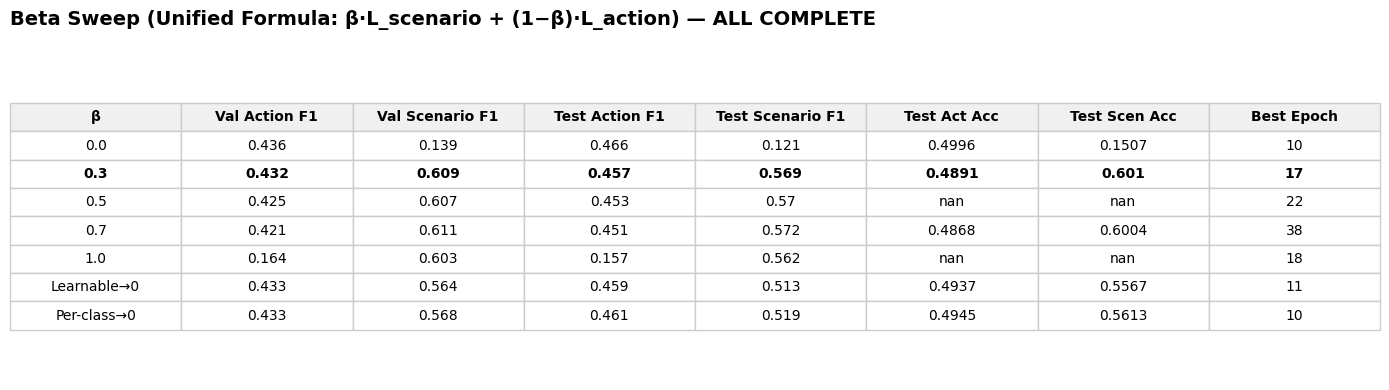

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
ax.set_title('Beta Sweep (Unified Formula: β·L_scenario + (1−β)·L_action) — ALL COMPLETE',
             fontsize=14, fontweight='bold', pad=20, loc='left')

cell_text = []
for _, row in df.iterrows():
    cell_text.append([v if v is not None else '—' for v in row.values])

col_labels = df.columns.tolist()
table = ax.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.6)

for j in range(len(col_labels)):
    cell = table[0, j]
    cell.set_text_props(fontweight='bold')
    cell.set_facecolor('#f0f0f0')
    cell.set_edgecolor('#cccccc')

# Bold the β=0.3 row
for j in range(len(col_labels)):
    table[2, j].set_text_props(fontweight='bold')

for i in range(1, len(cell_text) + 1):
    for j in range(len(col_labels)):
        cell = table[i, j]
        cell.set_edgecolor('#cccccc')
        cell.set_facecolor('white')

plt.tight_layout()
plt.savefig('beta_sweep_table.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [27]:
# Combined F1 = average of Test Action F1 and Test Scenario F1
# ALL "Ours" points share the same x-position (OURS_PARAMS)

# Ours β sweep points — derived from table
ours_points = {}
for beta_val in ['0.3']:
    row = df[df['β'] == beta_val].iloc[0]
    combined = (row['Test Action F1'] + row['Test Scenario F1']) / 2
    ours_points[f'Ours (β={beta_val})'] = combined

# Probe = β=0.0
##row_00 = df[df['β'] == '0.0'].iloc[0]
#ours_points['Ours (Probe)'] = (row_00['Test Action F1'] + row_00['Test Scenario F1']) / 2

# Baseline combined F1 (only those with both action & scenario F1)
baseline_combined = {}
for name, d in baselines.items():
    if d['scen_f1'] is not None:
        baseline_combined[name] = {
            'params': d['params'],
            'combined_f1': (d['act_f1'] + d['scen_f1']) / 2
        }

print("Ours combined F1 (all at x={:.3f}M):".format(OURS_PARAMS))
for k, v in ours_points.items():
    print(f"  {k}: {v:.4f}")
print("\nBaseline combined F1:")
for k, v in baseline_combined.items():
    print(f"  {k}: {v['combined_f1']:.4f} @ {v['params']}M")

Ours combined F1 (all at x=0.703M):
  Ours (β=0.3): 0.5130

Baseline combined F1:
  MLP-MLP: 0.4335 @ 1.03M
  IMU2CLIP: 0.4720 @ 4.0M
  CNN-MLP: 0.4450 @ 1.07M
  CNN-LSTM-GRU: 0.4430 @ 1.19M


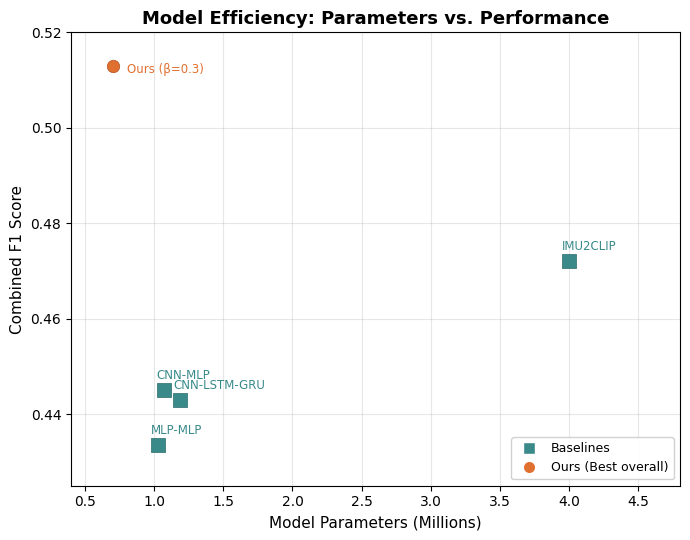

In [36]:
fig, ax = plt.subplots(figsize=(7, 5.5))

# Baselines (squares, teal)
for name, d in baseline_combined.items():
    ax.scatter(d['params'], d['combined_f1'], marker='s', s=90, color='#3a8a8a',
              edgecolors='#2a6a6a', linewidths=0.5, zorder=3)
    ax.annotate(name, (d['params'], d['combined_f1']),
               textcoords='offset points', xytext=(-5, 8),
               fontsize=8.5, color='#3a8a8a')

# Ours (circles, orange/coral — distinct from baselines)
ours_color = '#e07030'
label_offsets_eff = {
    'Ours (β=0.3)': (10, -5),
}
for name, combined_f1 in ours_points.items():
    ax.scatter(OURS_PARAMS, combined_f1, marker='o', s=80, color=ours_color,
              edgecolors='#b05020', linewidths=0.5, zorder=4)
    offset = label_offsets_eff.get(name, (10, 5))
    ax.annotate(name, (OURS_PARAMS, combined_f1),
               textcoords='offset points', xytext=offset,
               fontsize=8.5, color=ours_color)

legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#3a8a8a',
           markersize=9, label='Baselines'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=ours_color,
           markersize=9, label='Ours (Best overall)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)
ax.set_xlabel('Model Parameters (Millions)', fontsize=11)
ax.set_ylabel('Combined F1 Score', fontsize=11)
ax.set_title('Model Efficiency: Parameters vs. Performance', fontsize=13, fontweight='bold')
ax.set_xlim(0.4, 4.8)
ax.set_ylim(0.425, 0.52)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_efficiency.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [21]:
# β sweep points — from the table
sweep_betas = ['0.3', '0.5', '0.7', '1.0']
sweep_x = [df.loc[df['β'] == b, 'Test Action F1'].values[0] for b in sweep_betas]
sweep_y = [df.loc[df['β'] == b, 'Test Scenario F1'].values[0] for b in sweep_betas]

# Probe = β=0.0
probe_x = df.loc[df['β'] == '0.0', 'Test Action F1'].values[0]
probe_y = df.loc[df['β'] == '0.0', 'Test Scenario F1'].values[0]

# Baselines for Pareto (only those with both act & scen F1)
pareto_baselines = {}
pareto_styles = {
    'IMU2CLIP':     {'marker': 's', 'color': '#2a6a8a'},
    'CNN-MLP':      {'marker': 'D', 'color': '#e8a030'},
    'CNN-LSTM-GRU': {'marker': 'D', 'color': '#50a050'},
    'MLP-MLP':      {'marker': 'D', 'color': '#c04040'},
}
for name, d in baselines.items():
    if d['scen_f1'] is not None and name in pareto_styles:
        pareto_baselines[name] = {
            'action_f1': d['act_f1'],
            'scenario_f1': d['scen_f1'],
            **pareto_styles[name]
        }

print("Pareto plot coordinates (from table):")
for b, x, y in zip(sweep_betas, sweep_x, sweep_y):
    print(f"  β={b}: Action F1={x}, Scenario F1={y}")
print(f"  Probe (β=0.0): Action F1={probe_x}, Scenario F1={probe_y}")
print("\nBaselines:")
for name, d in pareto_baselines.items():
    print(f"  {name}: Action F1={d['action_f1']}, Scenario F1={d['scenario_f1']}")

Pareto plot coordinates (from table):
  β=0.3: Action F1=0.457, Scenario F1=0.569
  β=0.5: Action F1=0.453, Scenario F1=0.57
  β=0.7: Action F1=0.451, Scenario F1=0.572
  β=1.0: Action F1=0.157, Scenario F1=0.562
  Probe (β=0.0): Action F1=0.466, Scenario F1=0.121

Baselines:
  MLP-MLP: Action F1=0.339, Scenario F1=0.528
  IMU2CLIP: Action F1=0.385, Scenario F1=0.559
  CNN-MLP: Action F1=0.367, Scenario F1=0.523
  CNN-LSTM-GRU: Action F1=0.378, Scenario F1=0.508


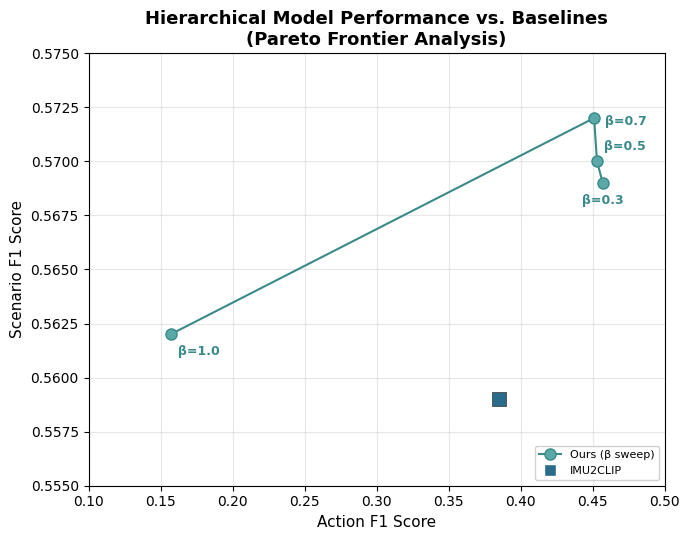

In [48]:
fig, ax = plt.subplots(figsize=(7, 5.5))

# β sweep connected line
ax.plot(sweep_x, sweep_y, 'o-', color='#3a8a8a', markersize=8, linewidth=1.5,
        markerfacecolor='#5aa8a8', markeredgecolor='#3a8a8a', zorder=4)

# Label each β point
pareto_offsets = {
    '0.3': (-15, -15),
    '0.5': (5, 8),
    '0.7': (8, -5),
    '1.0': (5, -15),
}
for b, x, y in zip(sweep_betas, sweep_x, sweep_y):
    ox, oy = pareto_offsets[b]
    ax.annotate(f'β={b}', (x, y), textcoords='offset points', xytext=(ox, oy),
               fontsize=9, fontweight='bold', color='#3a8a8a')

# Probe (star)
ax.scatter(probe_x, probe_y, marker='*', s=200, color='#2a2a2a',
          edgecolors='black', linewidths=0.5, zorder=5)

# Baselines
for name, d in pareto_baselines.items():
    ax.scatter(d['action_f1'], d['scenario_f1'], marker=d['marker'], s=100,
              color=d['color'], edgecolors='#333333', linewidths=0.5, zorder=3)

# "Best Action Prediction" circle around β=1.0
b10_x = df.loc[df['β'] == '1.0', 'Test Action F1'].values[0]
b10_y = df.loc[df['β'] == '1.0', 'Test Scenario F1'].values[0]

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='#3a8a8a', markerfacecolor='#5aa8a8',
           markersize=8, label='Ours (β sweep)', linewidth=1.5),

    Line2D([0], [0], marker='s', color='w', markerfacecolor='#2a6a8a',
           markersize=9, label='IMU2CLIP'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.9)
ax.set_xlabel('Action F1 Score', fontsize=11)
ax.set_ylabel('Scenario F1 Score', fontsize=11)
ax.set_title('Hierarchical Model Performance vs. Baselines\n(Pareto Frontier Analysis)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.555, 0.575)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pareto_frontier.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()